In [41]:
# Install required packages
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'wfdb', 'tqdm', '--quiet'])
print('Packages ready.')

Packages ready.


In [42]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


## 1. Imports & Environment Setup

In [43]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

print('All imports OK.')

All imports OK.


## 2. Paper Configuration (Section 3, Dudukcu et al. 2023)

In [44]:
# ── MIT-BIH Arrhythmia Database path ────────────────────────────────────────
# Update this to the local path where you extracted the MIT-BIH database.
DATA_DIR = r"/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0"

# ── Exact constants from the paper (Section 3) ───────────────────────────────
FS           = 360        # sampling frequency (360 samples/second)
TOTAL_STEPS  = 100_000    # '100,000 time-step ECG data' per patient
TRAIN_STEPS  = 40_000     # '40,000 time-steps for training'
VAL_STEPS    = 10_000     # '10,000 time-steps for validation'
TEST_STEPS   = 50_000     # '50,000 time-steps as test data'

LOOKBACK     = 10         # '10-time step history windows'
HORIZON      = 1          # 'one time-step of prediction horizon'

# ── 21 patients: full MIT-BIH set MINUS patients 111 and 118 ────────────────
# Paper: 'Patient 111 and Patient 118 from 23 patients were excluded
#         ... because models could not be trained correctly'
PATIENTS = [
    '100', '101', '102', '103', '104', '105',
    '106', '107', '108', '109', '112', '113',
    '114', '115', '116', '117', '119',
    '121', '122', '123', '124'
]
assert len(PATIENTS) == 21, f'Expected 21 patients, got {len(PATIENTS)}'

print(f'Patients         : {len(PATIENTS)}')
print(f'Sampling freq    : {FS} Hz')
print(f'Total steps/pt   : {TOTAL_STEPS:,}')
print(f'Train/Val/Test   : {TRAIN_STEPS:,} / {VAL_STEPS:,} / {TEST_STEPS:,}')
print(f'Lookback window  : {LOOKBACK} steps  →  {LOOKBACK/FS*1000:.1f} ms')
print(f'Pred horizon     : {HORIZON} step   →  {HORIZON/FS*1000:.1f} ms')
print(f'Excluded         : 111, 118 (paper: outlier values during benchmarking)')

Patients         : 21
Sampling freq    : 360 Hz
Total steps/pt   : 100,000
Train/Val/Test   : 40,000 / 10,000 / 50,000
Lookback window  : 10 steps  →  27.8 ms
Pred horizon     : 1 step   →  2.8 ms
Excluded         : 111, 118 (paper: outlier values during benchmarking)


## 3. Data Loading & Preprocessing

Pipeline follows Section 3 of the paper exactly:
1. Load MLII lead from MIT-BIH Arrhythmia Database using `wfdb`.
2. Truncate / pad to exactly `TOTAL_STEPS` samples.
3. Split: train (0–40k), validation (40k–50k), test (50k–100k).
4. Min-Max normalise — scaler fitted on **train only** to prevent leakage.
5. Build sliding-window sequences: X = 10 steps, y = next step (1-step-ahead).

In [45]:
def load_ecg_signal(record_id: str, data_dir: str, n_steps: int = 100_000) -> np.ndarray:
    """
    Load the MLII lead (or first available lead) from a MIT-BIH record
    and return exactly n_steps samples.

    Paper (Section 3.1): 'digitizing the two-channel ambulatory ECG recordings
    of a 24-hour period with a sampling frequency of 360 samples per second.'
    The amplitude is estimated 2 ms ahead using 28 ms history windows.
    Here we load the raw signal; history windowing is applied in make_sequences().
    """
    path = os.path.join(data_dir, record_id)
    rec  = wfdb.rdrecord(path)

    # Prefer MLII lead; fall back to first available channel
    sig_names_upper = [s.upper() for s in rec.sig_name]
    ch = sig_names_upper.index('MLII') if 'MLII' in sig_names_upper else 0

    signal = rec.p_signal[:, ch].astype(np.float32)

    # Pad with the last value if the recording is shorter than n_steps
    if len(signal) < n_steps:
        pad = np.full(n_steps - len(signal), signal[-1], dtype=np.float32)
        signal = np.concatenate([signal, pad])

    return signal[:n_steps]


def preprocess_patient(
    signal: np.ndarray,
    train_steps: int = 40_000,
    val_steps:   int = 10_000,
) -> tuple:
    """
    Split signal into train / val / test, then apply Min-Max normalisation.

    Paper (Section 3): 'For both datasets, 40,000 time-steps are separated
    for training data, 10,000 time-steps for validation data, and 50,000
    time-steps as test data.'

    Scaler is fitted on the training partition only to avoid data leakage.
    Returns: (train_norm, val_norm, test_norm, fitted_scaler)
    """
    train_end = train_steps
    val_end   = train_steps + val_steps

    train_raw = signal[:train_end]          # 0     – 39,999
    val_raw   = signal[train_end:val_end]   # 40,000 – 49,999
    test_raw  = signal[val_end:]            # 50,000 – 99,999

    scaler     = MinMaxScaler(feature_range=(0, 1))
    train_norm = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
    val_norm   = scaler.transform(val_raw.reshape(-1, 1)).flatten()
    test_norm  = scaler.transform(test_raw.reshape(-1, 1)).flatten()

    return train_norm, val_norm, test_norm, scaler


def make_sequences(
    signal:   np.ndarray,
    lookback: int = 10,
    horizon:  int = 1,
) -> tuple:
    """
    Build sliding-window (X, y) pairs for supervised time-series prediction.

    Paper (Section 3.2): '10-time step history windows for one time-step of
    prediction horizon' and 'the amplitude of the signal was estimated 2 ms
    ahead by using input data sequences with 28 ms history window.'
    (28 ms @ 360 Hz ≈ 10 samples; 2 ms @ 360 Hz ≈ 1 sample ahead)

    X[i] = signal[i : i+lookback]   shape (lookback,)
    y[i] = signal[i + lookback]     scalar
    """
    X, y = [], []
    for i in range(len(signal) - lookback - horizon + 1):
        X.append(signal[i : i + lookback])
        y.append(signal[i + lookback])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


print('Preprocessing functions defined.')
print(f'  load_ecg_signal()   — reads MLII lead, truncates/pads to {TOTAL_STEPS:,} steps')
print(f'  preprocess_patient() — splits {TRAIN_STEPS:,}/{VAL_STEPS:,}/{TEST_STEPS:,}, MinMax-normalises')
print(f'  make_sequences()    — sliding window: X={LOOKBACK} steps → y=1 step ahead')

Preprocessing functions defined.
  load_ecg_signal()   — reads MLII lead, truncates/pads to 100,000 steps
  preprocess_patient() — splits 40,000/10,000/50,000, MinMax-normalises
  make_sequences()    — sliding window: X=10 steps → y=1 step ahead


In [46]:
# patient_data[rid] contains the preprocessed split arrays and the fitted scaler.
# Structure: {'X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'scaler',
#             'train_norm', 'val_norm', 'test_norm'}
# The '*_norm' entries are the same normalised signals preprocess_patient() already
# computes on the line below — we simply keep them instead of discarding them, so
# Part 2's multi-horizon sequences (Section 7) can be built without re-loading,
# re-splitting, or re-fitting anything.
patient_data = {}

print(f'Loading and preprocessing {len(PATIENTS)} patients...\n')
for rid in tqdm(PATIENTS, desc='Patients'):
    # Step 1 — load raw signal
    signal = load_ecg_signal(rid, DATA_DIR, n_steps=TOTAL_STEPS)

    # Step 2 — split + normalise
    tr, vl, te, sc = preprocess_patient(signal, TRAIN_STEPS, VAL_STEPS)

    # Step 3 — build sliding-window sequences for each partition (1-step-ahead,
    # matching the paper exactly — used for verification and as the Recursive
    # strategy's base model training data in Part 2)
    X_tr, y_tr = make_sequences(tr, LOOKBACK, HORIZON)
    X_vl, y_vl = make_sequences(vl, LOOKBACK, HORIZON)
    X_te, y_te = make_sequences(te, LOOKBACK, HORIZON)

    patient_data[rid] = {
        'X_train': X_tr, 'y_train': y_tr,
        'X_val'  : X_vl, 'y_val'  : y_vl,
        'X_test' : X_te, 'y_test' : y_te,
        'scaler' : sc,
        'train_norm': tr, 'val_norm': vl, 'test_norm': te,
    }
    tqdm.write(
        f'  Patient {rid:>3s} | '
        f'train={X_tr.shape}  val={X_vl.shape}  test={X_te.shape}'
    )

print('\nAll patients loaded.')


Loading and preprocessing 21 patients...



Patients:   0%|          | 0/21 [00:00<?, ?it/s]

  Patient 100 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 101 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 102 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 103 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 104 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 105 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 106 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 107 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 108 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 109 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 112 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 113 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 114 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 115 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 116 | train=(39990, 10)  val=(9990, 10

## 4. Preprocessing Verification

Sanity-check that every patient's arrays match the shapes and value ranges
expected from the paper's description.

In [47]:
# ── Expected shapes from paper ───────────────────────────────────────────────
# train partition: 40,000 samples  → sequences: 40,000 - 10 - 1 + 1 = 39,990
# val   partition: 10,000 samples  →            10,000 - 10 - 1 + 1 =  9,990
# test  partition: 50,000 samples  →            50,000 - 10 - 1 + 1 = 49,990
EXP_TRAIN_N = TRAIN_STEPS - LOOKBACK - HORIZON + 1   # 39,990
EXP_VAL_N   = VAL_STEPS   - LOOKBACK - HORIZON + 1   #  9,990
EXP_TEST_N  = TEST_STEPS  - LOOKBACK - HORIZON + 1   # 49,990

print(f'Expected sequence counts:')
print(f'  Train : {EXP_TRAIN_N:,}')
print(f'  Val   : {EXP_VAL_N:,}')
print(f'  Test  : {EXP_TEST_N:,}\n')

all_ok = True
rows = []
for rid in PATIENTS:
    d = patient_data[rid]
    shape_ok  = (
        d['X_train'].shape == (EXP_TRAIN_N, LOOKBACK) and
        d['X_val'].shape   == (EXP_VAL_N,   LOOKBACK) and
        d['X_test'].shape  == (EXP_TEST_N,  LOOKBACK)
    )
    # After MinMax normalisation all values should be in [0, 1] for train
    scale_ok  = (
        float(d['X_train'].min()) >= -1e-6 and
        float(d['X_train'].max()) <=  1 + 1e-6
    )
    nan_ok    = not (np.isnan(d['X_train']).any() or np.isnan(d['X_test']).any())
    status    = '✅' if (shape_ok and scale_ok and nan_ok) else '❌'
    if not (shape_ok and scale_ok and nan_ok):
        all_ok = False
    rows.append({
        'Patient' : rid,
        'Train X' : str(d['X_train'].shape),
        'Val X'   : str(d['X_val'].shape),
        'Test X'  : str(d['X_test'].shape),
        'Scale OK': '✅' if scale_ok else '❌',
        'NaN free': '✅' if nan_ok  else '❌',
        'Status'  : status,
    })

df_check = pd.DataFrame(rows).set_index('Patient')
print(df_check.to_string())
print()
if all_ok:
    print('✅  All 21 patients pass shape, scale, and NaN checks.')
else:
    print('❌  One or more patients failed verification — check DATA_DIR and signal lengths.')

Expected sequence counts:
  Train : 39,990
  Val   : 9,990
  Test  : 49,990

             Train X       Val X       Test X Scale OK NaN free Status
Patient                                                               
100      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
101      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
102      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
103      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
104      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
105      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
106      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
107      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
108      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
109      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
112      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅


## 5. Signal Visualisation (Sanity Check)

Plot a representative segment from Patient 103 across all three partitions
to confirm the normalised signal looks physiologically plausible before training.

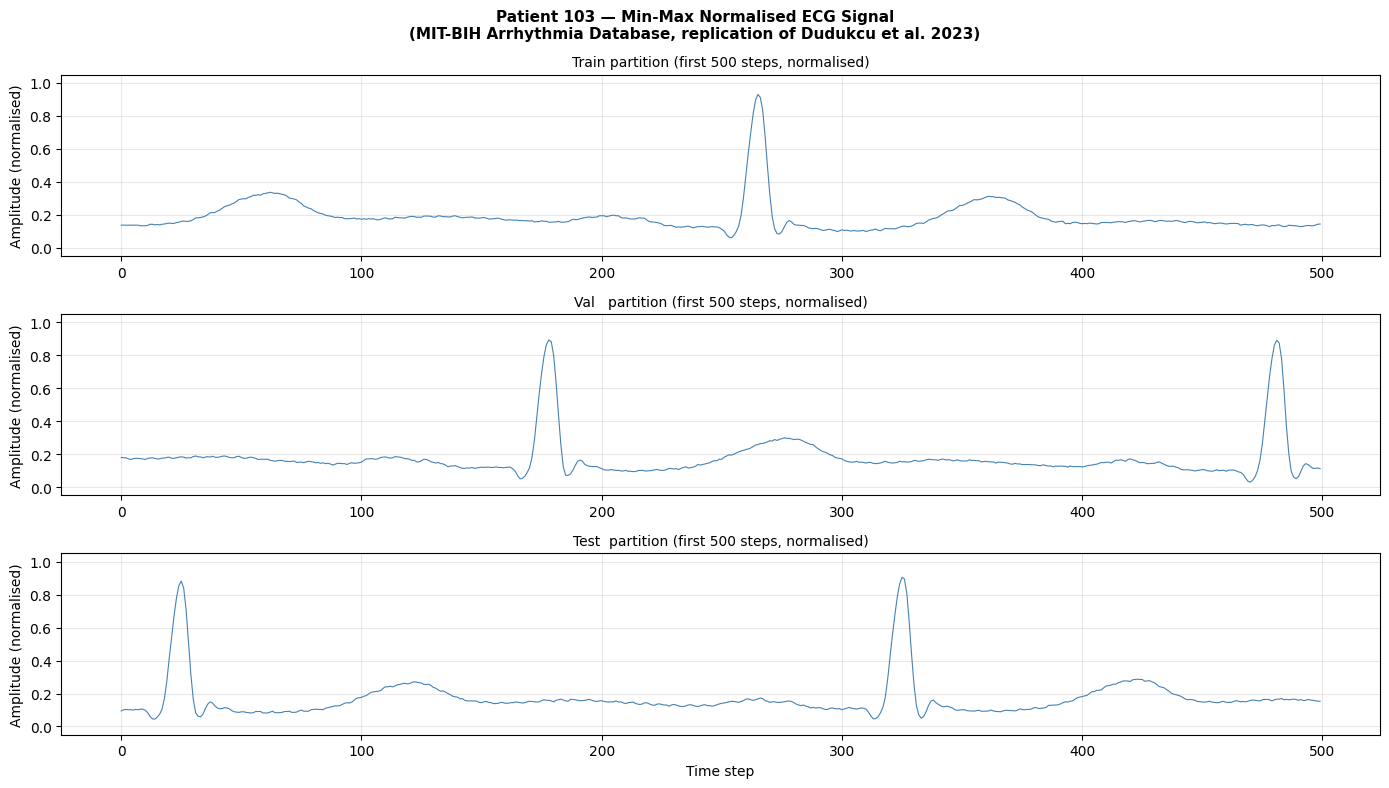

Plot saved to patient103_preprocessed.png


In [48]:
DEMO_PATIENT = '103'
d = patient_data[DEMO_PATIENT]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)

segments = [
    ('Train partition (first 500 steps, normalised)', d['X_train'][:500, 0]),
    ('Val   partition (first 500 steps, normalised)', d['X_val'][:500, 0]),
    ('Test  partition (first 500 steps, normalised)', d['X_test'][:500, 0]),
]
for ax, (title, seg) in zip(axes, segments):
    ax.plot(seg, linewidth=0.8, color='steelblue')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Amplitude (normalised)')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time step')
fig.suptitle(
    f'Patient {DEMO_PATIENT} — Min-Max Normalised ECG Signal\n'
    f'(MIT-BIH Arrhythmia Database, replication of Dudukcu et al. 2023)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('patient103_preprocessed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to patient103_preprocessed.png')

## 6. Preprocessing Summary

Aggregate statistics across all 21 patients to confirm consistency
before handing off to model training.

In [49]:
summary_rows = []
for rid in PATIENTS:
    d = patient_data[rid]
    summary_rows.append({
        'Patient'          : rid,
        'Train samples'    : d['X_train'].shape[0],
        'Val samples'      : d['X_val'].shape[0],
        'Test samples'     : d['X_test'].shape[0],
        'Train min'        : round(float(d['X_train'].min()), 4),
        'Train max'        : round(float(d['X_train'].max()), 4),
        'Test min'         : round(float(d['X_test'].min()),  4),
        'Test max'         : round(float(d['X_test'].max()),  4),
        'Scaler min (mV)'  : round(float(d['scaler'].data_min_[0]), 4),
        'Scaler max (mV)'  : round(float(d['scaler'].data_max_[0]), 4),
    })

df_summary = pd.DataFrame(summary_rows).set_index('Patient')
print('Preprocessing summary (all 21 patients):')
display(df_summary)

print(f'\nX shape per sample : ({LOOKBACK},)  →  ready for model input')
print(f'y shape per sample : scalar (1-step-ahead amplitude)')
print(f'\npreprocessing complete — patient_data dict is ready for training.')

Preprocessing summary (all 21 patients):


,Train samples,Val samples,Test samples,Train min,Train max,Test min,Test max,Scaler min (mV),Scaler max (mV)
Patient,,,,,,,,,
100,39990,9990,49990,0.0,1.0,0.0000,1.0659,-0.695,1.125
101,39990,9990,49990,0.0,1.0,-0.6421,1.1146,-1.130,2.055
102,39990,9990,49990,0.0,1.0,0.2442,0.8797,-1.410,1.375
103,39990,9990,49990,0.0,1.0,-0.0036,1.0267,-0.760,2.045
104,39990,9990,49990,0.0,1.0,-0.2539,1.0875,-1.195,1.720
105,39990,9990,49990,0.0,1.0,-0.0018,1.0018,-0.790,1.965
106,39990,9990,49990,0.0,1.0,0.0134,0.9946,-1.520,2.200
107,39990,9990,49990,0.0,1.0,0.0330,0.9280,-3.105,2.800
108,39990,9990,49990,0.0,1.0,-0.1002,0.9087,-1.165,1.080



X shape per sample : (10,)  →  ready for model input
y shape per sample : scalar (1-step-ahead amplitude)

preprocessing complete — patient_data dict is ready for training.


---
# Part 2 — Multi-Horizon ECG Forecasting: Recursive, Direct & MIMO Strategies

Section 6 confirmed `patient_data` is correct and consistent for all 21
patients. Part 2 uses it directly and asks a new question: **how well can we
forecast further into the future, not just 1 step ahead?**

**Horizons.** ECG amplitude in this dataset is sampled at `FS = 360`
samples/second (Section 2). A "horizon" of `h` steps means the model is
asked to predict the amplitude `h` samples after the end of its 10-step
lookback window. We evaluate three horizons:

| Horizon (steps) | Time ahead (steps ÷ FS) |
|---|---|
| 10  | 10/360 s ≈ 27.8 ms |
| 20  | 20/360 s ≈ 55.6 ms |
| 50  | 50/360 s ≈ 138.9 ms |

These are short compared to a full heartbeat (~0.6–1 s at 60–100 bpm), so
horizon 50 still forecasts *within* the current beat or just into the next —
but far enough ahead that simple 1-step extrapolation starts to break down,
which is exactly what this experiment is designed to expose.

**Strategies.** Three standard multi-step forecasting strategies are
implemented and compared at every horizon:

* **Recursive** — train one 1-step-ahead model; forecast further by feeding
  its own predictions back in as input, step by step.
* **Direct** — train a separate model per horizon that maps the lookback
  window straight to that horizon's target, skipping the steps in between.
* **MIMO** (Multi-Input Multi-Output) — train a single model with one output
  per horizon, predicting all three simultaneously from one forward pass.

Sections below are kept strictly separated: feature preparation (7), model
definition (8), strategy implementations (9), hyperparameters (10), training
(11), evaluation (12), the full experiment (13), results aggregation (14),
failure analysis (15), and visualizations (16).

## 7. Multi-Horizon Feature Preparation

Direct and MIMO both need targets at `t + 10`, `t + 20`, `t + 50` — targets
the original 1-step preprocessing (Section 3) never computed. This section
builds those windows **directly from the already-normalised, already-split
signals retained in `patient_data['train_norm'/'val_norm'/'test_norm']`** —
the same arrays Section 3 produced, same scaler, same train/val/test
boundaries. No record is re-loaded, no scaler is re-fit, no split point
moves. The Recursive strategy needs none of this — it reuses
`patient_data['X_train']/['y_train']` (Section 3) unchanged.

In [50]:
FORECAST_HORIZONS = [10, 20, 50]     # steps ahead (see table above for ms equivalents)
MAX_HORIZON = max(FORECAST_HORIZONS)


def build_multihorizon_sequences(signal: np.ndarray, lookback: int, horizons: list) -> tuple:
    """
    Build (X, Y) from an already-normalised 1-D signal.

    X[i]    = signal[i : i+lookback]                          shape (lookback,)
    Y[i, j] = signal[i + lookback + horizons[j] - 1]           shape (len(horizons),)

    horizons[j] = 1 reproduces Section 3's make_sequences() target exactly;
    horizons=[10, 20, 50] gives the three multi-step targets used below.
    """
    signal = np.asarray(signal, dtype=np.float32)
    max_h = max(horizons)
    n = len(signal) - lookback - max_h + 1
    row_idx = np.arange(n)[:, None] + np.arange(lookback)[None, :]
    X = signal[row_idx]
    Y = np.stack([signal[np.arange(n) + lookback + h - 1] for h in horizons], axis=1).astype(np.float32)
    return X, Y


multi_data = {}
print(f'Building multi-horizon sequences (horizons={FORECAST_HORIZONS}) for {len(PATIENTS)} patients...\n')
for rid in tqdm(PATIENTS, desc='Patients'):
    d = patient_data[rid]
    X_tr, Y_tr = build_multihorizon_sequences(d['train_norm'], LOOKBACK, FORECAST_HORIZONS)
    X_vl, Y_vl = build_multihorizon_sequences(d['val_norm'],   LOOKBACK, FORECAST_HORIZONS)
    X_te, Y_te = build_multihorizon_sequences(d['test_norm'],  LOOKBACK, FORECAST_HORIZONS)
    multi_data[rid] = {
        'X_train': X_tr, 'Y_train': Y_tr,
        'X_val'  : X_vl, 'Y_val'  : Y_vl,
        'X_test' : X_te, 'Y_test' : Y_te,
    }

demo = multi_data[PATIENTS[0]]
print(f"Patient {PATIENTS[0]} shapes — X_train:{demo['X_train'].shape}  "
      f"Y_train:{demo['Y_train'].shape}  X_test:{demo['X_test'].shape}  Y_test:{demo['Y_test'].shape}")
assert demo['Y_train'].shape[1] == len(FORECAST_HORIZONS)
print('\nMulti-horizon sequences built for all 21 patients — no new records loaded, no new scalers fit.')


Building multi-horizon sequences (horizons=[10, 20, 50]) for 21 patients...



Patients:   0%|          | 0/21 [00:00<?, ?it/s]

Patient 100 shapes — X_train:(39941, 10)  Y_train:(39941, 3)  X_test:(49941, 10)  Y_test:(49941, 3)

Multi-horizon sequences built for all 21 patients — no new records loaded, no new scalers fit.


## 8. Model Architecture

Same Transformer encoder design as before, generalised with an `output_dim`
argument so the identical class serves all three strategies:

* `output_dim=1` — Recursive's 1-step base model, and each of Direct's
  per-horizon models.
* `output_dim=len(FORECAST_HORIZONS)=3` — MIMO's single multi-output model.

In [51]:
import math
import time
import copy

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding (Vaswani et al., 2017)."""

    def __init__(self, d_model: int, max_len: int = 100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1), :]


class ECGTransformerForecaster(nn.Module):
    """
    Transformer encoder for ECG amplitude forecasting.

    Input : (batch, LOOKBACK)                       — normalised amplitude history
    Output: (batch,)  if output_dim == 1             — single-horizon forecast
            (batch, output_dim) if output_dim > 1    — multi-horizon (MIMO) forecast
    """

    def __init__(
        self,
        seq_len: int = 10,
        d_model: int = 32,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 64,
        dropout: float = 0.1,
        output_dim: int = 1,
    ):
        super().__init__()
        self.output_dim = output_dim
        self.input_proj = nn.Linear(1, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=seq_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Linear(d_model // 2, output_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.unsqueeze(-1)
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x[:, -1, :]
        out = self.output_head(x)                 # (batch, output_dim)
        return out.squeeze(-1) if self.output_dim == 1 else out


print('Model architecture defined: ECGTransformerForecaster (shared by all 3 strategies).')


Using device: cuda
Model architecture defined: ECGTransformerForecaster (shared by all 3 strategies).


## 9. Forecasting Strategies

`recursive_forecast()` is the only strategy-specific inference function
needed — Direct and MIMO just call the trained model once on
`multi_data[rid]['X_test']`. Recursive instead calls its 1-step model
repeatedly, sliding its own last prediction into the input window, and
records the output at every step in `FORECAST_HORIZONS` along the way.

In [52]:
def recursive_forecast(model: nn.Module, X_input: np.ndarray, horizons: list, device: torch.device) -> dict:
    """
    Roll a 1-step model forward MAX_HORIZON times. Returns {horizon: preds_norm}
    for every horizon in `horizons`, using the same rolled trajectory (so an
    h=50 forecast naturally passes through, and reuses, the h=10 and h=20 steps).
    """
    model.eval()
    max_h = max(horizons)
    horizon_set = set(horizons)
    window = torch.from_numpy(X_input.copy()).to(device)   # (N, lookback)
    preds = {}
    with torch.no_grad():
        for step in range(1, max_h + 1):
            out = model(window)                             # (N,)
            if step in horizon_set:
                preds[step] = out.cpu().numpy()
            window = torch.cat([window[:, 1:], out.unsqueeze(1)], dim=1)
    return preds


print('recursive_forecast() defined — Direct and MIMO need no extra inference logic beyond a single forward pass.')


recursive_forecast() defined — Direct and MIMO need no extra inference logic beyond a single forward pass.


## 10. Hyperparameters & Model Initialization

In [53]:
HP = dict(
    d_model=32,
    nhead=4,
    num_layers=2,
    dim_feedforward=64,
    dropout=0.1,
    batch_size=256,
    lr=1e-3,
    weight_decay=1e-5,
    epochs=200,
    patience=50,
)

print('Hyperparameters (shared architecture/optimiser settings across all strategies):')
for k, v in HP.items():
    print(f'  {k:>15s}: {v}')
print(f'\nForecast horizons: {FORECAST_HORIZONS} steps  →  '
      f'{[round(h/FS*1000,1) for h in FORECAST_HORIZONS]} ms @ {FS} Hz')
print('Strategies        : Recursive, Direct, MIMO')
print(f'Models per patient: 1 (Recursive) + {len(FORECAST_HORIZONS)} (Direct) + 1 (MIMO) '
      f'= {2 + len(FORECAST_HORIZONS)}')


def build_model(output_dim: int = 1, seq_len: int = LOOKBACK) -> ECGTransformerForecaster:
    """Fresh, randomly initialized model."""
    torch.manual_seed(SEED)
    return ECGTransformerForecaster(
        seq_len=seq_len, d_model=HP['d_model'], nhead=HP['nhead'],
        num_layers=HP['num_layers'], dim_feedforward=HP['dim_feedforward'],
        dropout=HP['dropout'], output_dim=output_dim,
    ).to(device)


_tmp = build_model(output_dim=1)
n_params_single = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
_tmp_mimo = build_model(output_dim=len(FORECAST_HORIZONS))
n_params_mimo = sum(p.numel() for p in _tmp_mimo.parameters() if p.requires_grad)
print(f'\nSingle-output model : {n_params_single:,} trainable parameters')
print(f'MIMO (3-output) model: {n_params_mimo:,} trainable parameters')
del _tmp, _tmp_mimo


Hyperparameters (shared architecture/optimiser settings across all strategies):
          d_model: 32
            nhead: 4
       num_layers: 2
  dim_feedforward: 64
          dropout: 0.1
       batch_size: 256
               lr: 0.001
     weight_decay: 1e-05
           epochs: 200
         patience: 50

Forecast horizons: [10, 20, 50] steps  →  [27.8, 55.6, 138.9] ms @ 360 Hz
Strategies        : Recursive, Direct, MIMO
Models per patient: 1 (Recursive) + 3 (Direct) + 1 (MIMO) = 5

Single-output model : 17,697 trainable parameters
MIMO (3-output) model: 17,731 trainable parameters


## 11. Training & Validation Procedure

One generic function trains any of the three strategies' models — the only
difference between them is what `X`/`y` arrays and `output_dim` are passed
in. Adam + MSE loss; validation loss (computed each epoch, no gradient
updates) drives early stopping and best-checkpoint selection, exactly as in
the single-horizon experiment.

In [54]:
def make_loader(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=False)


def train_model(X_train, y_train, X_val, y_val, hp: dict, device: torch.device, output_dim: int = 1):
    """Generic trainer used for the Recursive base model, each Direct model, and MIMO."""
    model = build_model(output_dim=output_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=hp['lr'], weight_decay=hp['weight_decay'])
    loss_fn = nn.MSELoss()

    train_loader = make_loader(X_train, y_train, hp['batch_size'], shuffle=True)
    val_loader = make_loader(X_val, y_val, hp['batch_size'], shuffle=False)

    best_val_loss = float('inf')
    best_state = None
    patience_ctr = 0
    history = {'train_loss': [], 'val_loss': []}

    t0 = time.time()
    for epoch in range(hp['epochs']):
        model.train()
        running, n_seen = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
            n_seen += xb.size(0)
        train_loss = running / n_seen

        model.eval()
        running, n_seen = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                running += loss_fn(pred, yb).item() * xb.size(0)
                n_seen += xb.size(0)
        val_loss = running / n_seen

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= hp['patience']:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    train_time = time.time() - t0

    return model, history, train_time


print('train_model() defined — one trainer, reused for Recursive / Direct / MIMO.')


train_model() defined — one trainer, reused for Recursive / Direct / MIMO.


### 11b. Fast trainer (drop-in replacement for `train_model`)

`train_model()` above is correct but slow at this scale: a fresh `DataLoader`
per model, a host→device transfer every batch, and a `.item()` sync every
batch add up over 105 models. `train_model_fast()` does the exact same
computation — same architecture, same Adam+MSE, same early-stopping logic —
but moves each split to the device once, batches with `torch.randperm` on
the device instead of a `DataLoader`, evaluates validation in a single
forward pass (these val sets are small), and only syncs the loss to CPU
once per epoch instead of once per batch.

In [55]:
torch.backends.cudnn.benchmark = True
if hasattr(torch.backends.cuda, 'matmul'):
    torch.backends.cuda.matmul.allow_tf32 = True

USE_AMP = (device.type == 'cuda')


def train_model_fast(X_train, y_train, X_val, y_val, hp: dict, device: torch.device,
                      output_dim: int = 1, batch_size: int = 4096):
    """Same model/optimiser/early-stopping as train_model(), rewritten to avoid
    DataLoader + per-batch host<->device sync overhead. Safe drop-in replacement:
    returns the identical (model, history, train_time) tuple."""
    model = build_model(output_dim=output_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=hp['lr'], weight_decay=hp['weight_decay'])
    loss_fn = nn.MSELoss()
    scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    # Move each split to device ONCE (not once per batch, not once per epoch).
    Xtr = torch.from_numpy(X_train).to(device, non_blocking=True)
    Ytr = torch.from_numpy(y_train).to(device, non_blocking=True)
    Xvl = torch.from_numpy(X_val).to(device, non_blocking=True)
    Yvl = torch.from_numpy(y_val).to(device, non_blocking=True)

    n_train = Xtr.shape[0]
    bs = min(batch_size, n_train)

    best_val_loss = float('inf')
    best_state = None
    patience_ctr = 0
    history = {'train_loss': [], 'val_loss': []}

    t0 = time.time()
    for epoch in range(hp['epochs']):
        model.train()
        perm = torch.randperm(n_train, device=device)
        running, n_seen = torch.zeros((), device=device), 0
        for start in range(0, n_train, bs):
            idx = perm[start:start + bs]
            xb, yb = Xtr[idx], Ytr[idx]
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                pred = model(xb)
                loss = loss_fn(pred, yb)
            scaler_amp.scale(loss).backward()
            scaler_amp.step(optimizer)
            scaler_amp.update()
            running += loss.detach() * xb.size(0)
            n_seen += xb.size(0)
        train_loss = (running / n_seen).item()   # single sync per epoch

        model.eval()
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=USE_AMP):
            # Val sets here are small enough (<= ~10k rows, d_model=32) to score
            # in one shot -- no need to chunk or sync per batch.
            val_pred = model(Xvl)
            val_loss = loss_fn(val_pred, Yvl).item()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= hp['patience']:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    train_time = time.time() - t0

    return model, history, train_time


print('train_model_fast() defined -- same math as train_model(), no per-batch DataLoader/sync overhead.')


train_model_fast() defined -- same math as train_model(), no per-batch DataLoader/sync overhead.


## 12. Testing / Evaluation Procedure & Metrics

All predictions and targets are inverse-transformed with the patient's own
fitted scaler before scoring — the scaler maps normalised amplitude back to
mV regardless of which horizon a value belongs to, so the same
`inverse_transform` call is valid for every strategy and horizon. RMSE, MAE,
and R² are computed per (patient, strategy, horizon).

In [56]:
def inverse_scale(values: np.ndarray, scaler) -> np.ndarray:
    shape = values.shape
    return scaler.inverse_transform(values.reshape(-1, 1)).reshape(shape)


def compute_metrics(y_true_mv: np.ndarray, y_pred_mv: np.ndarray) -> dict:
    rmse = float(np.sqrt(mean_squared_error(y_true_mv, y_pred_mv)))
    mae = float(mean_absolute_error(y_true_mv, y_pred_mv))
    r2 = float(r2_score(y_true_mv, y_pred_mv))
    return dict(RMSE=rmse, MAE=mae, R2=r2)


print('inverse_scale() / compute_metrics() defined — RMSE / MAE / R\u00b2 in original ECG amplitude units (mV).')


inverse_scale() / compute_metrics() defined — RMSE / MAE / R² in original ECG amplitude units (mV).


In [57]:
REP_PATIENT = PATIENTS[0]

strategy_results = []
demo_predictions = {}   # (strategy, horizon) -> (y_true_mv, y_pred_mv), REP_PATIENT only
demo_histories = {}     # strategy -> loss history, REP_PATIENT only

print(f'Training {len(PATIENTS)} patients \u00d7 3 strategies '
      f'({2 + len(FORECAST_HORIZONS)} models/patient, {len(PATIENTS)*(2+len(FORECAST_HORIZONS))} models total)...\n')

for rid in tqdm(PATIENTS, desc='Patients'):
    d1 = patient_data[rid]     # original 1-step data (Section 3, unchanged)
    dm = multi_data[rid]       # multi-horizon data (Section 7)
    scaler = d1['scaler']
    is_rep = (rid == REP_PATIENT)

    # ---------------- Recursive ----------------
    rec_model, rec_hist, rec_time = train_model_fast(
        d1['X_train'], d1['y_train'], d1['X_val'], d1['y_val'], HP, device, output_dim=1
    )
    rec_preds_norm = recursive_forecast(rec_model, dm['X_test'], FORECAST_HORIZONS, device)
    if is_rep:
        demo_histories['Recursive'] = rec_hist
    for j, h in enumerate(FORECAST_HORIZONS):
        y_true_mv = inverse_scale(dm['Y_test'][:, j], scaler)
        y_pred_mv = inverse_scale(rec_preds_norm[h], scaler)
        m = compute_metrics(y_true_mv, y_pred_mv)
        strategy_results.append(dict(Patient=rid, Strategy='Recursive', Horizon=h, TrainTime=rec_time, **m))
        if is_rep:
            demo_predictions[('Recursive', h)] = (y_true_mv, y_pred_mv)

    # ---------------- Direct ----------------
    for j, h in enumerate(FORECAST_HORIZONS):
        dir_model, dir_hist, dir_time = train_model_fast(
            dm['X_train'], dm['Y_train'][:, j], dm['X_val'], dm['Y_val'][:, j], HP, device, output_dim=1
        )
        with torch.no_grad():
            pred_norm = dir_model(torch.from_numpy(dm['X_test']).to(device)).cpu().numpy()
        y_true_mv = inverse_scale(dm['Y_test'][:, j], scaler)
        y_pred_mv = inverse_scale(pred_norm, scaler)
        m = compute_metrics(y_true_mv, y_pred_mv)
        strategy_results.append(dict(Patient=rid, Strategy='Direct', Horizon=h, TrainTime=dir_time, **m))
        if is_rep:
            demo_predictions[('Direct', h)] = (y_true_mv, y_pred_mv)
            demo_histories[f'Direct_h{h}'] = dir_hist

    # ---------------- MIMO ----------------
    mimo_model, mimo_hist, mimo_time = train_model_fast(
        dm['X_train'], dm['Y_train'], dm['X_val'], dm['Y_val'], HP, device, output_dim=len(FORECAST_HORIZONS)
    )
    with torch.no_grad():
        pred_norm_all = mimo_model(torch.from_numpy(dm['X_test']).to(device)).cpu().numpy()   # (N, 3)
    if is_rep:
        demo_histories['MIMO'] = mimo_hist
    for j, h in enumerate(FORECAST_HORIZONS):
        y_true_mv = inverse_scale(dm['Y_test'][:, j], scaler)
        y_pred_mv = inverse_scale(pred_norm_all[:, j], scaler)
        m = compute_metrics(y_true_mv, y_pred_mv)
        strategy_results.append(dict(Patient=rid, Strategy='MIMO', Horizon=h, TrainTime=mimo_time, **m))
        if is_rep:
            demo_predictions[('MIMO', h)] = (y_true_mv, y_pred_mv)

    tqdm.write(
        f'  Patient {rid:>3s} done | '
        + ' | '.join(
            f"{s}: RMSE(h={h})={next(r['RMSE'] for r in strategy_results if r['Patient']==rid and r['Strategy']==s and r['Horizon']==h):.4f}"
            for s in ['Recursive', 'Direct', 'MIMO'] for h in [FORECAST_HORIZONS[-1]]
        )
    )

print('\nTraining and evaluation complete: 21 patients \u00d7 3 strategies \u00d7 3 horizons.')


Training 21 patients × 3 strategies (5 models/patient, 105 models total)...



Patients:   0%|          | 0/21 [00:00<?, ?it/s]

  Patient 100 done | Recursive: RMSE(h=50)=0.2021 | Direct: RMSE(h=50)=0.1470 | MIMO: RMSE(h=50)=0.1492
  Patient 101 done | Recursive: RMSE(h=50)=0.2843 | Direct: RMSE(h=50)=0.2670 | MIMO: RMSE(h=50)=0.2601
  Patient 102 done | Recursive: RMSE(h=50)=0.2840 | Direct: RMSE(h=50)=0.1818 | MIMO: RMSE(h=50)=0.1767
  Patient 103 done | Recursive: RMSE(h=50)=0.4441 | Direct: RMSE(h=50)=0.3003 | MIMO: RMSE(h=50)=0.2812
  Patient 104 done | Recursive: RMSE(h=50)=0.4532 | Direct: RMSE(h=50)=0.2803 | MIMO: RMSE(h=50)=0.2809
  Patient 105 done | Recursive: RMSE(h=50)=0.3171 | Direct: RMSE(h=50)=0.2318 | MIMO: RMSE(h=50)=0.2298
  Patient 106 done | Recursive: RMSE(h=50)=0.7370 | Direct: RMSE(h=50)=0.3142 | MIMO: RMSE(h=50)=0.3155
  Patient 107 done | Recursive: RMSE(h=50)=1.3788 | Direct: RMSE(h=50)=0.6525 | MIMO: RMSE(h=50)=0.6517
  Patient 108 done | Recursive: RMSE(h=50)=0.2058 | Direct: RMSE(h=50)=0.1920 | MIMO: RMSE(h=50)=0.1918
  Patient 109 done | Recursive: RMSE(h=50)=0.5287 | Direct: RMSE

## 14. Results Aggregation Across All 21 Patients

In [79]:
df_strategy = pd.DataFrame(strategy_results)

# Save full results
df_strategy.to_csv(
    'multihorizon_strategy_results_full.csv',
    index=False
)

strategy_order = ['Direct', 'MIMO', 'Recursive']

df_strategy['Strategy'] = pd.Categorical(
    df_strategy['Strategy'],
    categories=strategy_order,
    ordered=True
)

# Sort everything
df_strategy = df_strategy.sort_values(
    by=['Patient', 'Strategy', 'Horizon']
).reset_index(drop=True)

all_patients = sorted(df_strategy['Patient'].unique())

print("=" * 120)
print("ALL PATIENT RESULTS")
print("=" * 120)
print(f"Total patients: {len(all_patients)}")

for patient_num, patient in enumerate(all_patients, start=1):

    print("\n")
    print("=" * 120)
    print(f"PATIENT {patient_num}/21  →  Patient ID: {patient}")
    print("=" * 120)

    patient_df = df_strategy[
        df_strategy['Patient'] == patient
    ]

    for strategy in strategy_order:

        strategy_df = patient_df[
            patient_df['Strategy'] == strategy
        ]

        print(f"\n--- {strategy.upper()} ---")

        display(
            strategy_df[
                [
                    'Patient',
                    'Strategy',
                    'Horizon',
                    'RMSE',
                    'MAE',
                    'R2',
                    'TrainTime'
                ]
            ].round(4)
        )

print("\n")
print("=" * 120)
print("SUMMARY")
print("=" * 120)

print(f"Number of patients: {len(all_patients)}")
print(f"Strategies: {', '.join(strategy_order)}")
print(
    f"Horizons: "
    f"{sorted(df_strategy['Horizon'].unique())}"
)

agg = (
    df_strategy
    .groupby(
        ['Strategy', 'Horizon'],
        observed=True
    )[
        ['RMSE', 'MAE', 'R2', 'TrainTime']
    ]
    .agg(['mean', 'std'])
    .round(4)
)

print("\n")
print("=" * 120)
print("AGGREGATE STATISTICS — ALL 21 PATIENTS")
print("=" * 120)

display(agg)

rmse_pivot = (
    df_strategy
    .pivot_table(
        index='Strategy',
        columns='Horizon',
        values='RMSE',
        aggfunc='mean'
    )
    .reindex(strategy_order)
    .round(4)
)

print("\nMean RMSE (mV) — Strategy × Horizon:")
display(rmse_pivot)

mae_pivot = (
    df_strategy
    .pivot_table(
        index='Strategy',
        columns='Horizon',
        values='MAE',
        aggfunc='mean'
    )
    .reindex(strategy_order)
    .round(4)
)

print("\nMean MAE (mV) — Strategy × Horizon:")
display(mae_pivot)

r2_pivot = (
    df_strategy
    .pivot_table(
        index='Strategy',
        columns='Horizon',
        values='R2',
        aggfunc='mean'
    )
    .reindex(strategy_order)
    .round(4)
)

print("\nMean R² — Strategy × Horizon:")
display(r2_pivot)

best_rmse = (
    df_strategy
    .groupby('Strategy', observed=True)['RMSE']
    .mean()
    .idxmin()
)

best_mae = (
    df_strategy
    .groupby('Strategy', observed=True)['MAE']
    .mean()
    .idxmin()
)

print("\n")
print("=" * 120)
print("BEST STRATEGIES")
print("=" * 120)

print(
    f"Best strategy by mean RMSE: {best_rmse}"
)

print(
    f"Best strategy by mean MAE:  {best_mae}"
)

print("\nSaved:")
print("multihorizon_strategy_results_full.csv")

ALL PATIENT RESULTS
Total patients: 21


PATIENT 1/21  →  Patient ID: 100

--- DIRECT ---


,Patient,Strategy,Horizon,RMSE,MAE,R2,TrainTime
0,100,Direct,10,0.0772,0.0355,0.8053,40.9948
1,100,Direct,20,0.1678,0.0771,0.0803,40.9188
2,100,Direct,50,0.1470,0.0803,0.2946,40.9750



--- MIMO ---


,Patient,Strategy,Horizon,RMSE,MAE,R2,TrainTime
3,100,MIMO,10,0.0781,0.0366,0.8010,41.0303
4,100,MIMO,20,0.1663,0.0736,0.0965,41.0303
5,100,MIMO,50,0.1492,0.0818,0.2729,41.0303



--- RECURSIVE ---


...


Mean MAE (mV) — Strategy × Horizon:


Horizon,10,20,50
Strategy,,,
Direct,0.0823,0.1477,0.1763
MIMO,0.0894,0.1446,0.1766
Recursive,0.1184,0.1960,0.2849



Mean R² — Strategy × Horizon:


Horizon,10,20,50
Strategy,,,
Direct,0.7133,0.3438,0.2843
MIMO,0.6777,0.3555,0.2987
Recursive,0.4086,-0.0623,-0.4718




BEST STRATEGIES
Best strategy by mean RMSE: Direct
Best strategy by mean MAE:  Direct

Saved:
multihorizon_strategy_results_full.csv


In [72]:
all_patients = sorted(df_strategy['Patient'].unique())
print("ALL PATIENTS")
print("=" * 50)

for i, patient in enumerate(all_patients, start=1):
    print(f"{i:2d}. Patient {patient}")

print("=" * 50)
print(f"Total number of patients: {len(all_patients)}")

ALL PATIENTS
 1. Patient 100
 2. Patient 101
 3. Patient 102
 4. Patient 103
 5. Patient 104
 6. Patient 105
 7. Patient 106
 8. Patient 107
 9. Patient 108
10. Patient 109
11. Patient 112
12. Patient 113
13. Patient 114
14. Patient 115
15. Patient 116
16. Patient 117
17. Patient 119
18. Patient 121
19. Patient 122
20. Patient 123
21. Patient 124
Total number of patients: 21


Randomly selected patients:
['100' '121' '117' '101' '108']


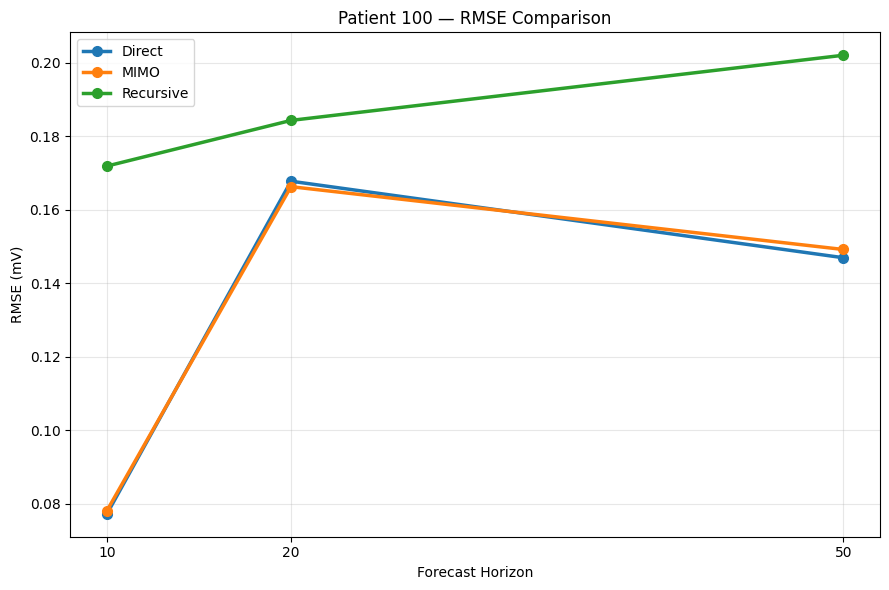

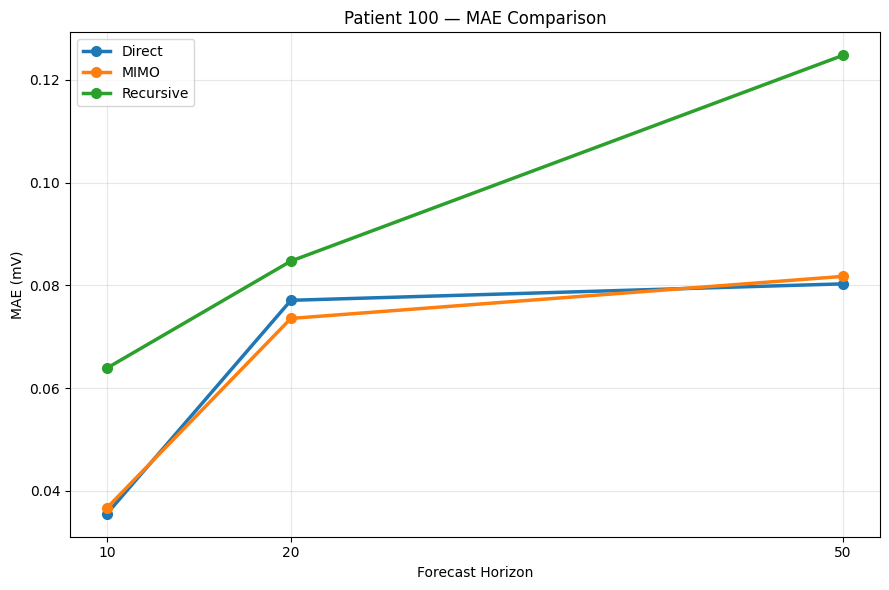

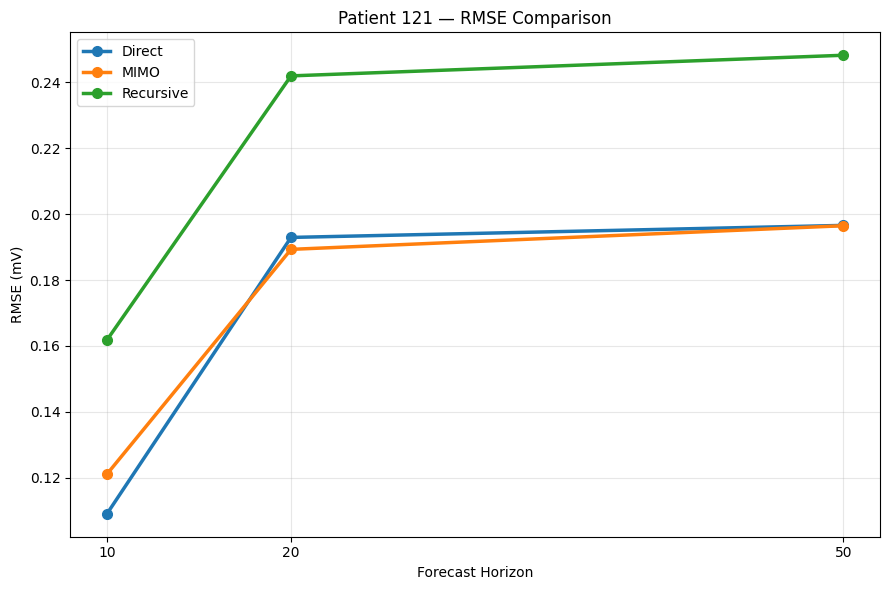

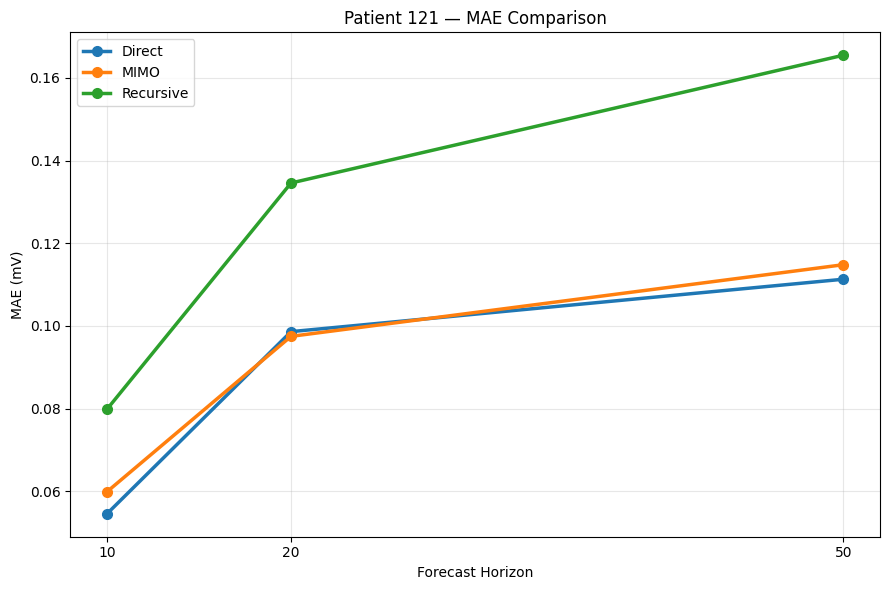

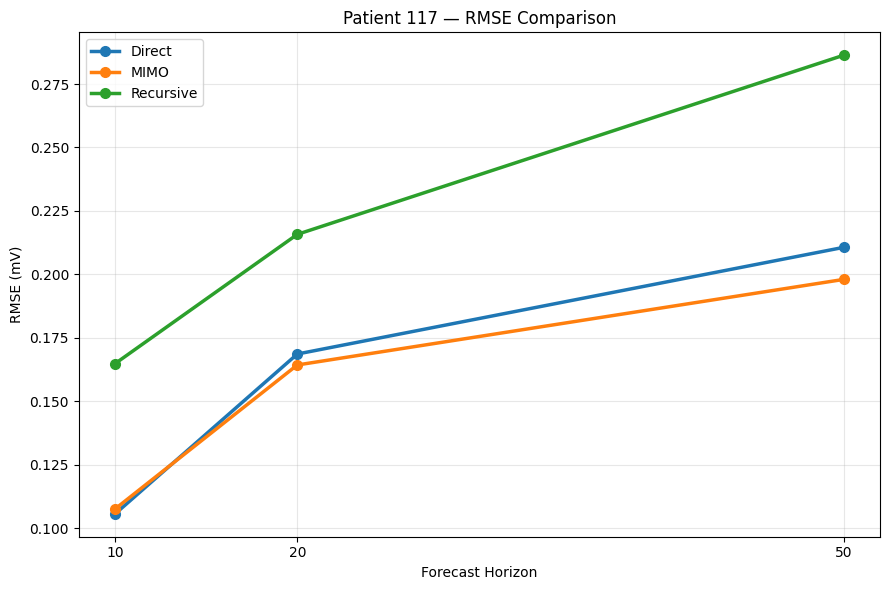

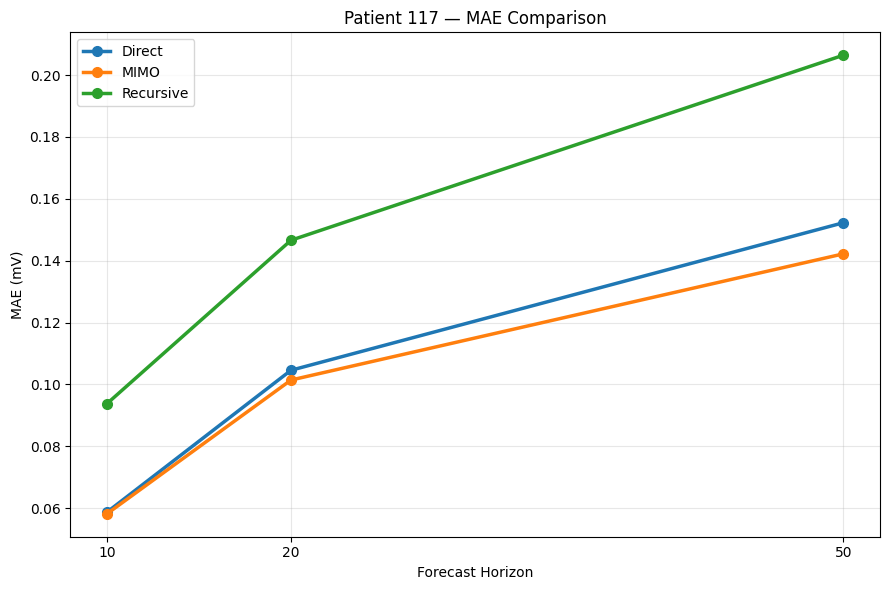

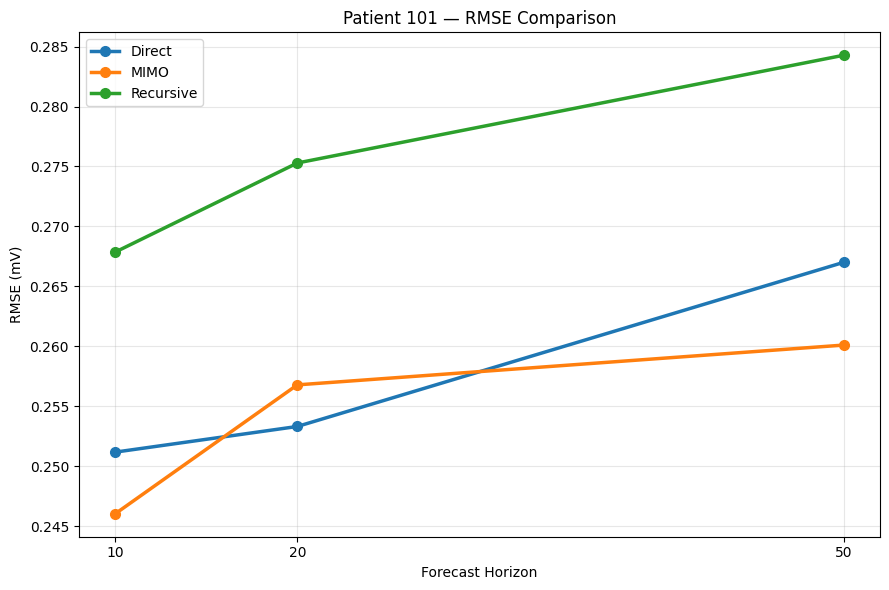

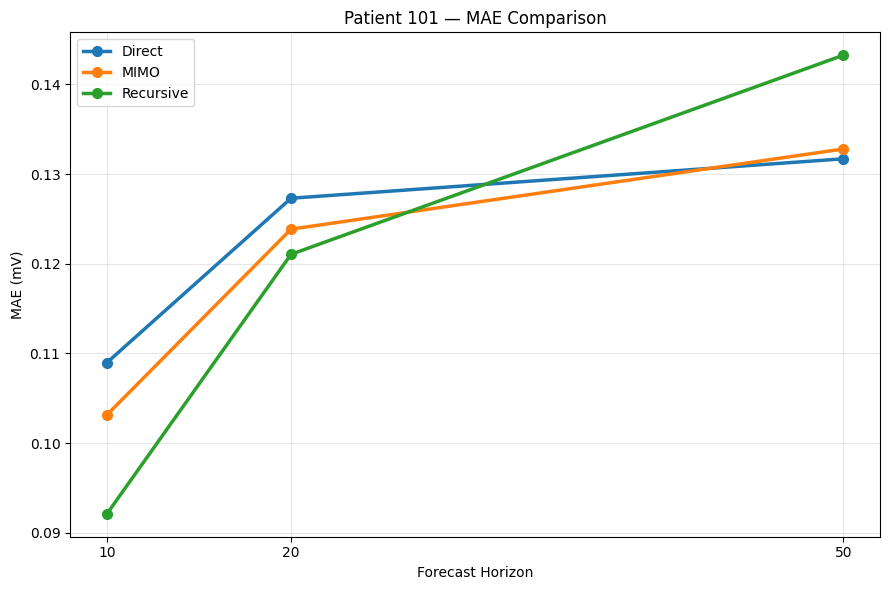

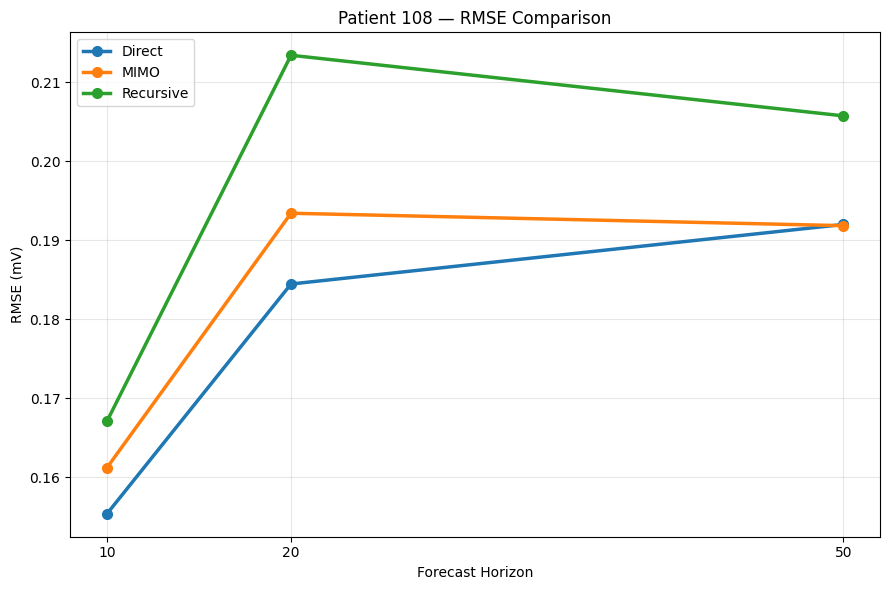

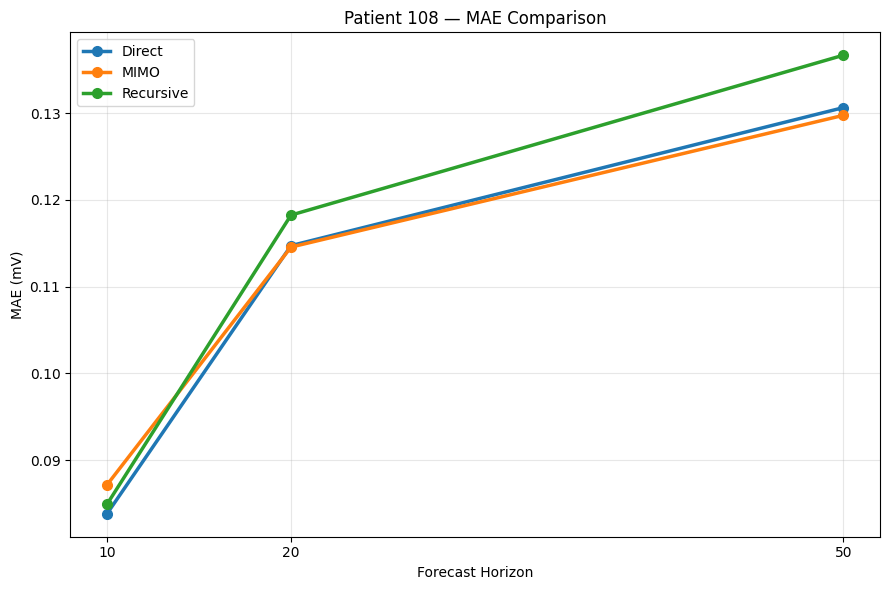

In [67]:
np.random.seed(42)

all_patients = df_strategy['Patient'].unique()

random_patients = np.random.choice(
    all_patients,
    size=5,
    replace=False
)

print("Randomly selected patients:")
print(random_patients)

# Desired strategy order
strategy_order = ['Direct', 'MIMO', 'Recursive']
for patient in random_patients:

    patient_df = df_strategy[
        df_strategy['Patient'] == patient
    ].copy()

    patient_df['Strategy'] = pd.Categorical(
        patient_df['Strategy'],
        categories=strategy_order,
        ordered=True
    )

    plt.figure(figsize=(9, 6))

    for strategy in strategy_order:

        strategy_df = patient_df[
            patient_df['Strategy'] == strategy
        ].sort_values('Horizon')

        plt.plot(
            strategy_df['Horizon'],
            strategy_df['RMSE'],
            marker='o',
            linewidth=2.5,
            markersize=7,
            label=strategy
        )

    plt.xlabel('Forecast Horizon')
    plt.ylabel('RMSE (mV)')
    plt.title(f'Patient {patient} — RMSE Comparison')
    plt.xticks(sorted(patient_df['Horizon'].unique()))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 6))

    for strategy in strategy_order:

        strategy_df = patient_df[
            patient_df['Strategy'] == strategy
        ].sort_values('Horizon')

        plt.plot(
            strategy_df['Horizon'],
            strategy_df['MAE'],
            marker='o',
            linewidth=2.5,
            markersize=7,
            label=strategy
        )

    plt.xlabel('Forecast Horizon')
    plt.ylabel('MAE (mV)')
    plt.title(f'Patient {patient} — MAE Comparison')
    plt.xticks(sorted(patient_df['Horizon'].unique()))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 15. Failure Analysis — Where Each Model Fails

Two views of failure: (a) how error grows with horizon for each strategy —
the direct measure of "how far ahead can this approach still forecast
reliably", and (b) *where in the signal* errors concentrate for the
representative patient — testing whether failures cluster around the fast
QRS transient (the spike) rather than the slow baseline, which is the
physiologically meaningful failure mode for ECG forecasting.

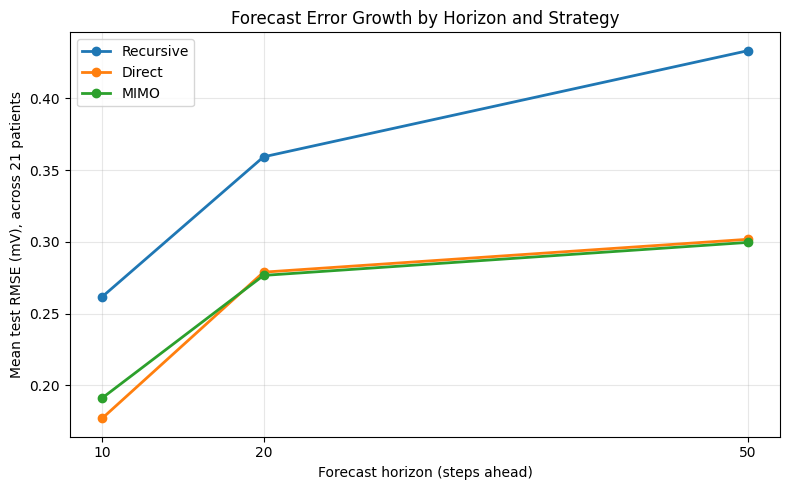

In [59]:
# 15a. RMSE vs. horizon, one line per strategy — degradation curve
fig, ax = plt.subplots(figsize=(8, 5))
for strat in ['Recursive', 'Direct', 'MIMO']:
    sub = df_strategy[df_strategy['Strategy'] == strat].groupby('Horizon')['RMSE'].mean()
    ax.plot(sub.index, sub.values, marker='o', label=strat, linewidth=2)
ax.set_xlabel('Forecast horizon (steps ahead)')
ax.set_ylabel('Mean test RMSE (mV), across 21 patients')
ax.set_title('Forecast Error Growth by Horizon and Strategy')
ax.set_xticks(FORECAST_HORIZONS)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rmse_vs_horizon_by_strategy.png', dpi=150, bbox_inches='tight')
plt.show()


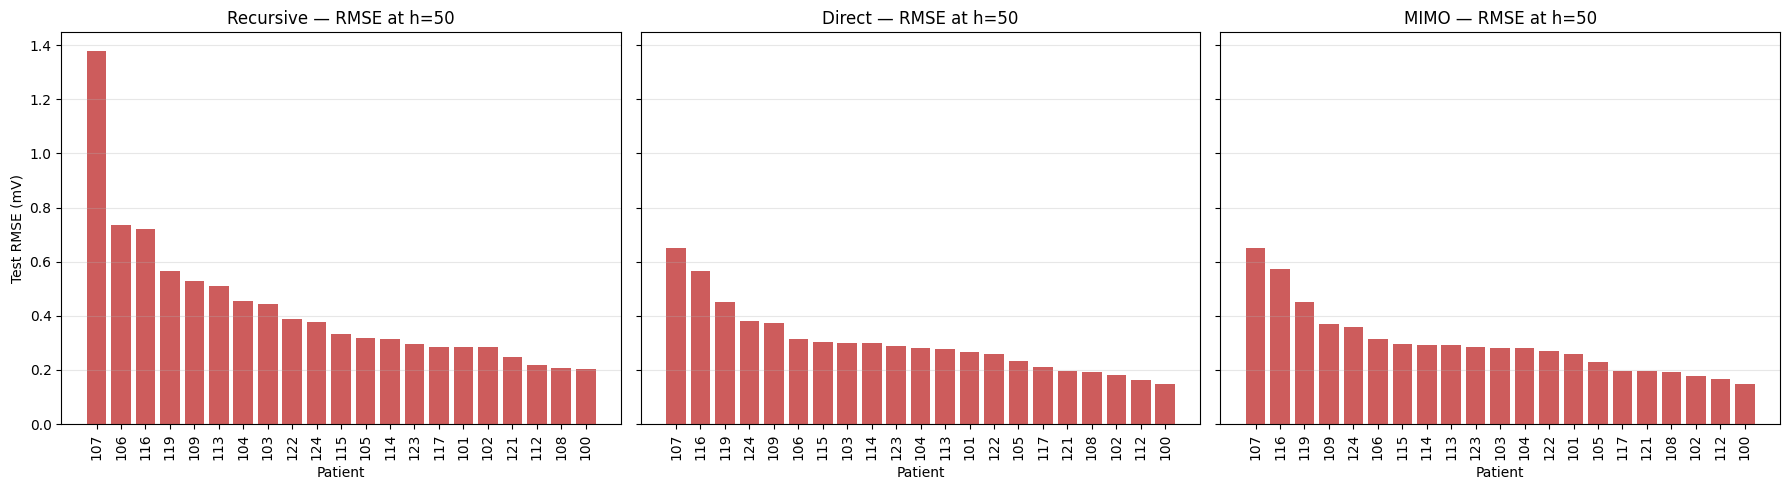

In [60]:
# 15b. Hardest patients at the longest horizon (h=50) — where does each strategy struggle most?
h_worst = FORECAST_HORIZONS[-1]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, strat in zip(axes, ['Recursive', 'Direct', 'MIMO']):
    sub = df_strategy[(df_strategy['Strategy'] == strat) & (df_strategy['Horizon'] == h_worst)]
    sub = sub.sort_values('RMSE', ascending=False).set_index('Patient')
    ax.bar(sub.index, sub['RMSE'], color='indianred')
    ax.set_title(f'{strat} — RMSE at h={h_worst}')
    ax.set_xlabel('Patient')
    ax.tick_params(axis='x', rotation=90)
    ax.grid(True, alpha=0.3, axis='y')
axes[0].set_ylabel('Test RMSE (mV)')
plt.tight_layout()
plt.savefig('hardest_patients_per_strategy.png', dpi=150, bbox_inches='tight')
plt.show()


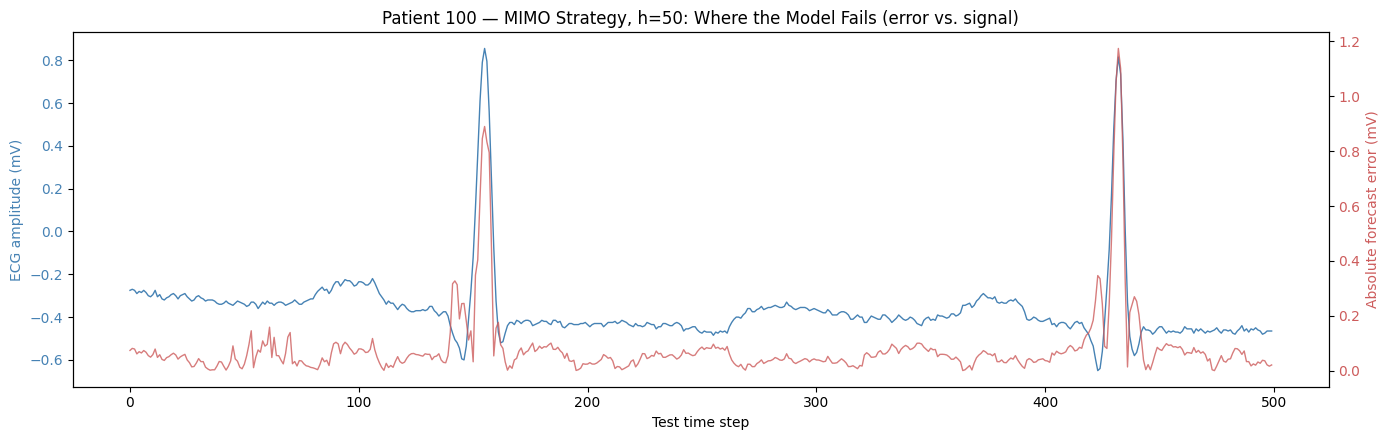

Mean |error| near QRS-like peaks (top 10% |amplitude|): 0.2428 mV
Mean |error| on baseline (remaining 90%):                0.0634 mV
Ratio (peak error / baseline error): 3.83x


In [61]:
# 15c. Where in the signal does the best strategy fail? (representative patient, hardest horizon)
best_strategy_h50 = (
    df_strategy[df_strategy['Horizon'] == h_worst]
    .groupby('Strategy')['RMSE'].mean().idxmin()
)
y_true_mv, y_pred_mv = demo_predictions[(best_strategy_h50, h_worst)]
abs_err = np.abs(y_true_mv - y_pred_mv)
n_show = min(500, len(y_true_mv))

fig, ax1 = plt.subplots(figsize=(14, 4.5))
ax1.plot(y_true_mv[:n_show], color='steelblue', linewidth=1.0, label='Actual amplitude (mV)')
ax1.set_xlabel('Test time step')
ax1.set_ylabel('ECG amplitude (mV)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(abs_err[:n_show], color='indianred', linewidth=1.0, alpha=0.8, label='Absolute error (mV)')
ax2.set_ylabel('Absolute forecast error (mV)', color='indianred')
ax2.tick_params(axis='y', labelcolor='indianred')

ax1.set_title(
    f'Patient {REP_PATIENT} — {best_strategy_h50} Strategy, h={h_worst}: '
    f'Where the Model Fails (error vs. signal)'
)
fig.tight_layout()
plt.savefig('failure_localization.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify: is error higher near large-amplitude (QRS) points than near baseline?
threshold = np.percentile(np.abs(y_true_mv), 90)
qrs_mask = np.abs(y_true_mv) >= threshold
print(f'Mean |error| near QRS-like peaks (top 10% |amplitude|): {abs_err[qrs_mask].mean():.4f} mV')
print(f'Mean |error| on baseline (remaining 90%):                {abs_err[~qrs_mask].mean():.4f} mV')
print(f'Ratio (peak error / baseline error): {abs_err[qrs_mask].mean() / abs_err[~qrs_mask].mean():.2f}x')


## 16. Actual vs. Predicted Visualizations

Selected random patients:
1. Patient 100
2. Patient 121
3. Patient 117
4. Patient 101
5. Patient 108


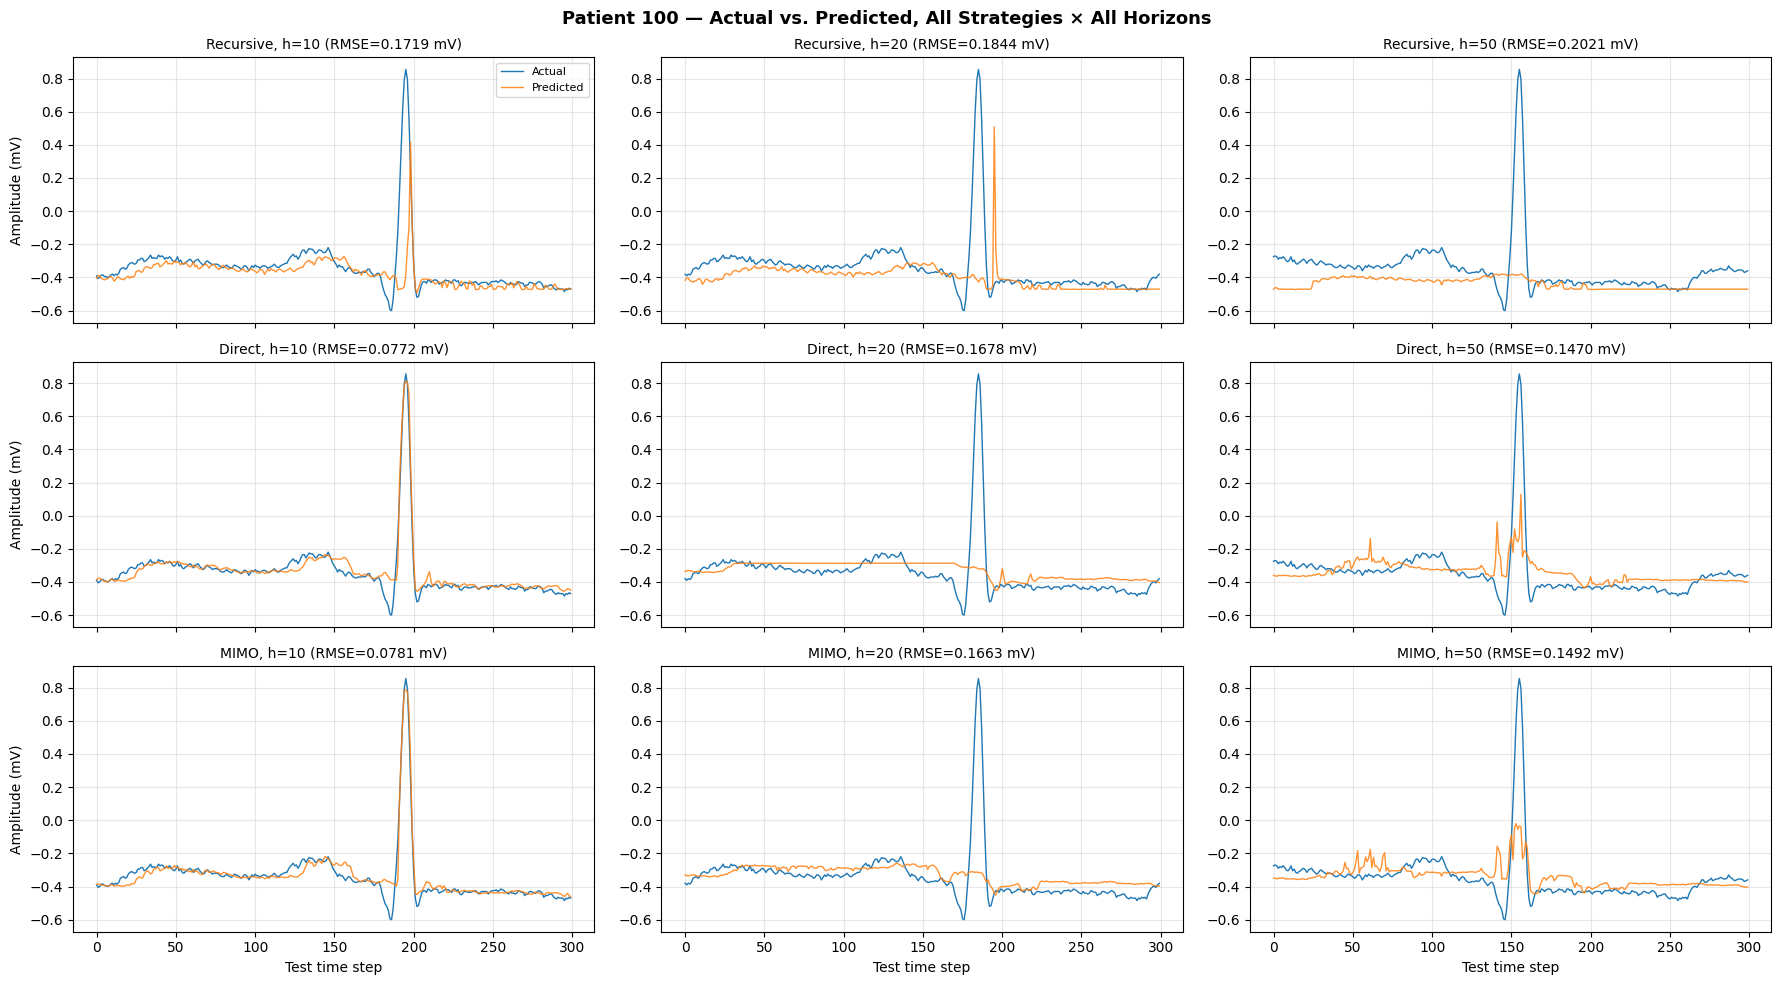

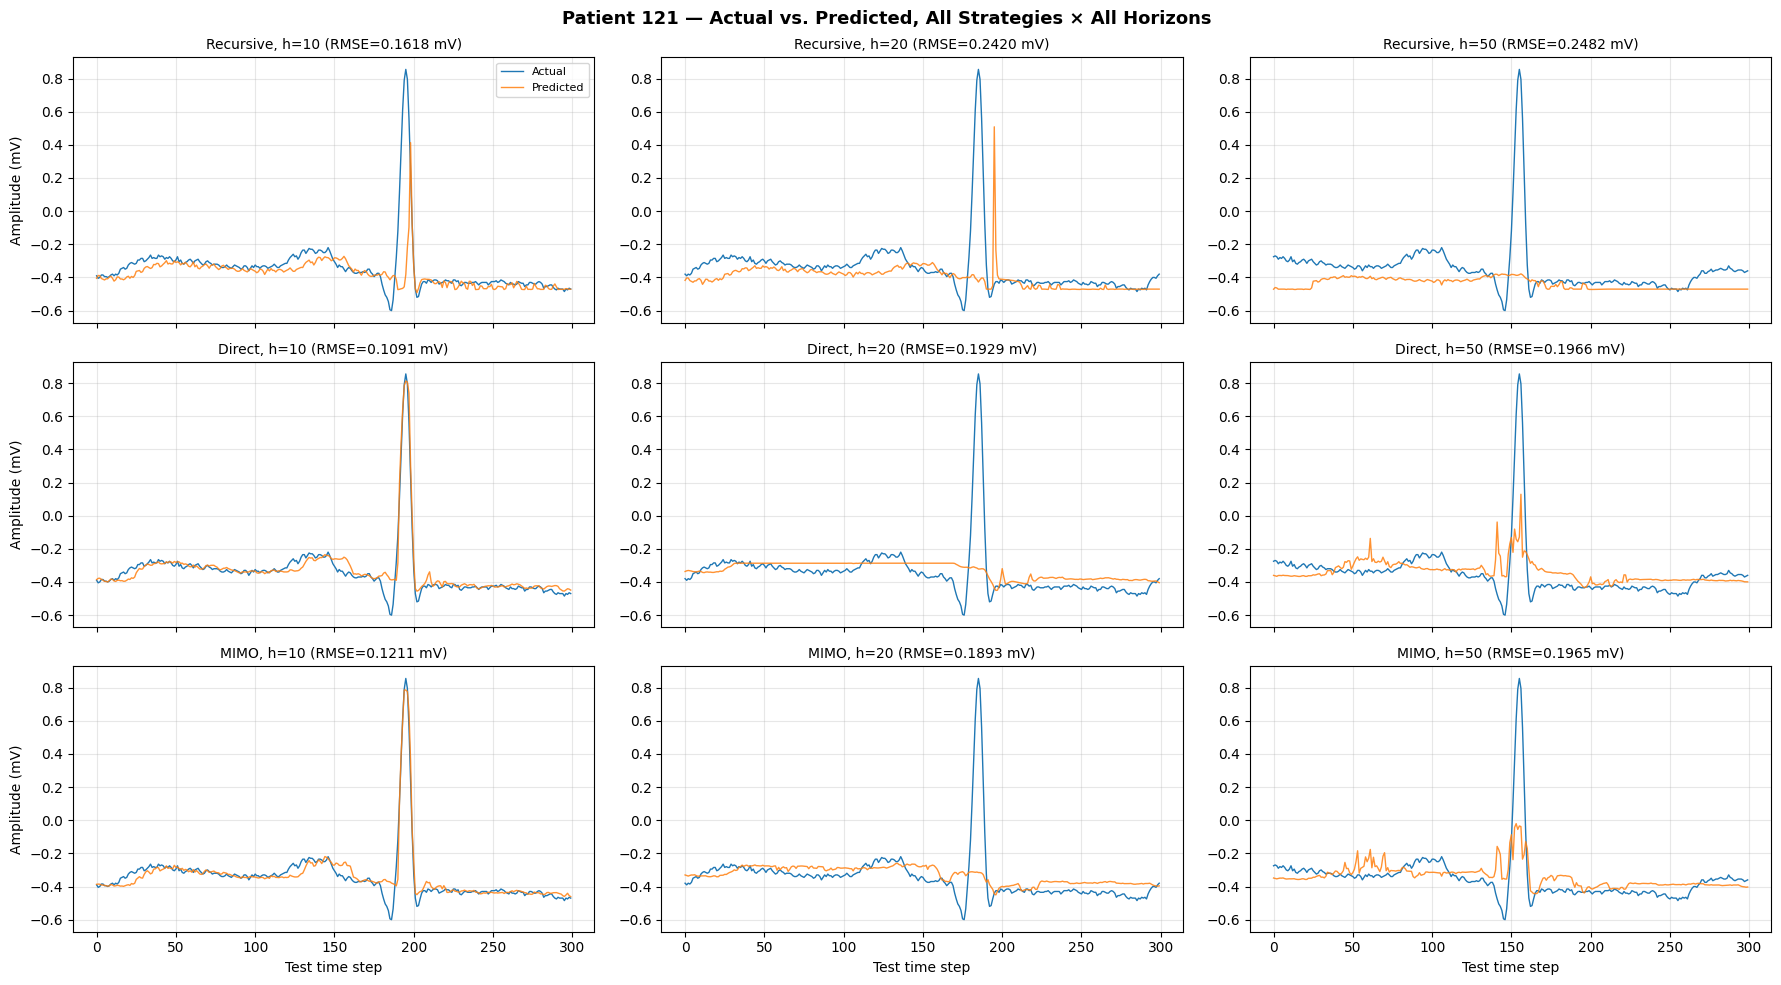

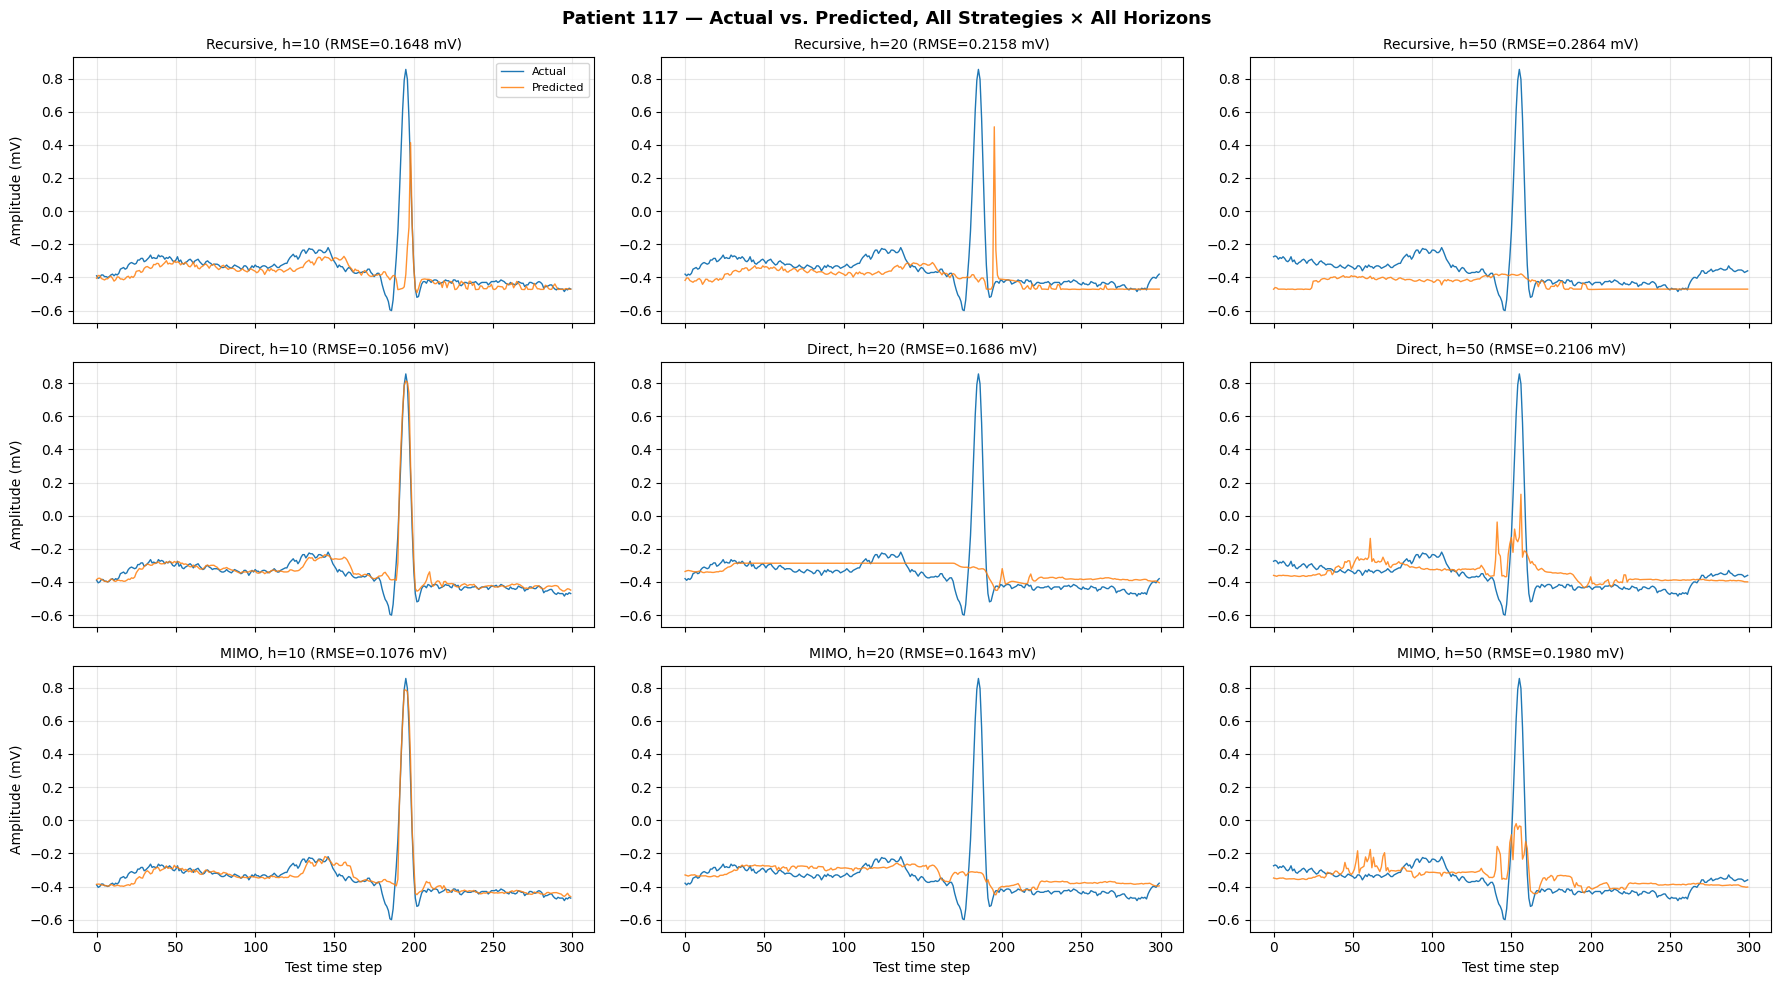

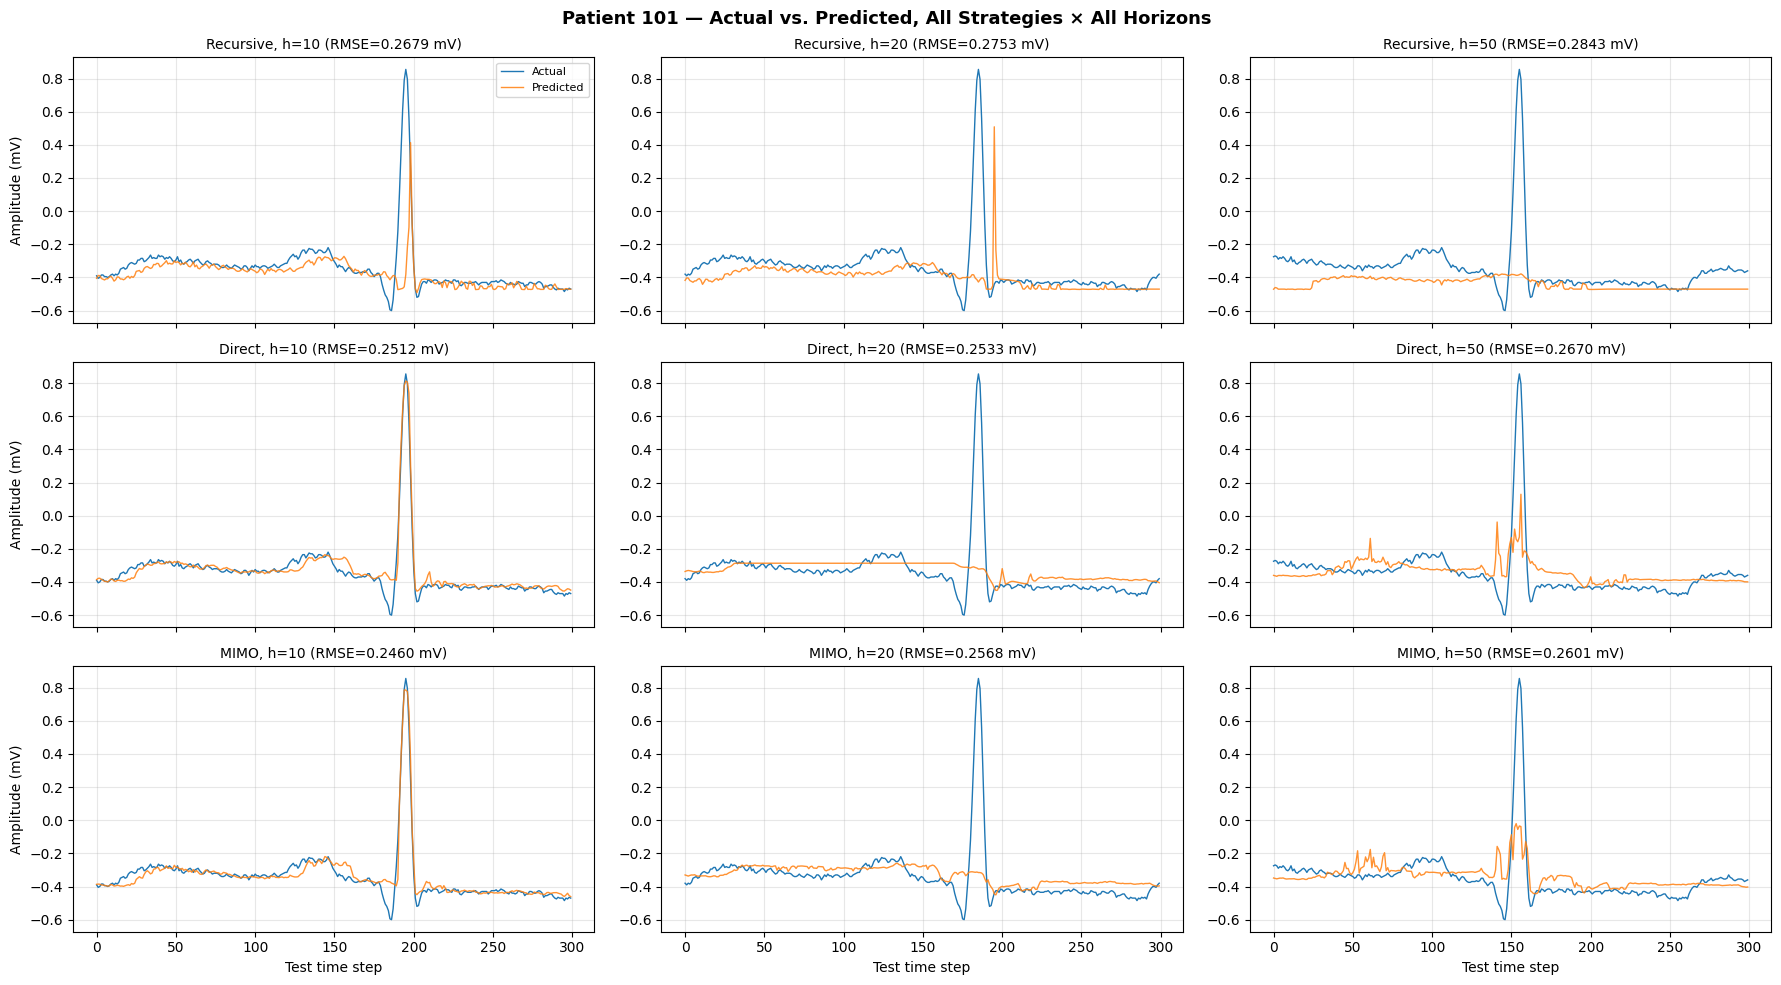

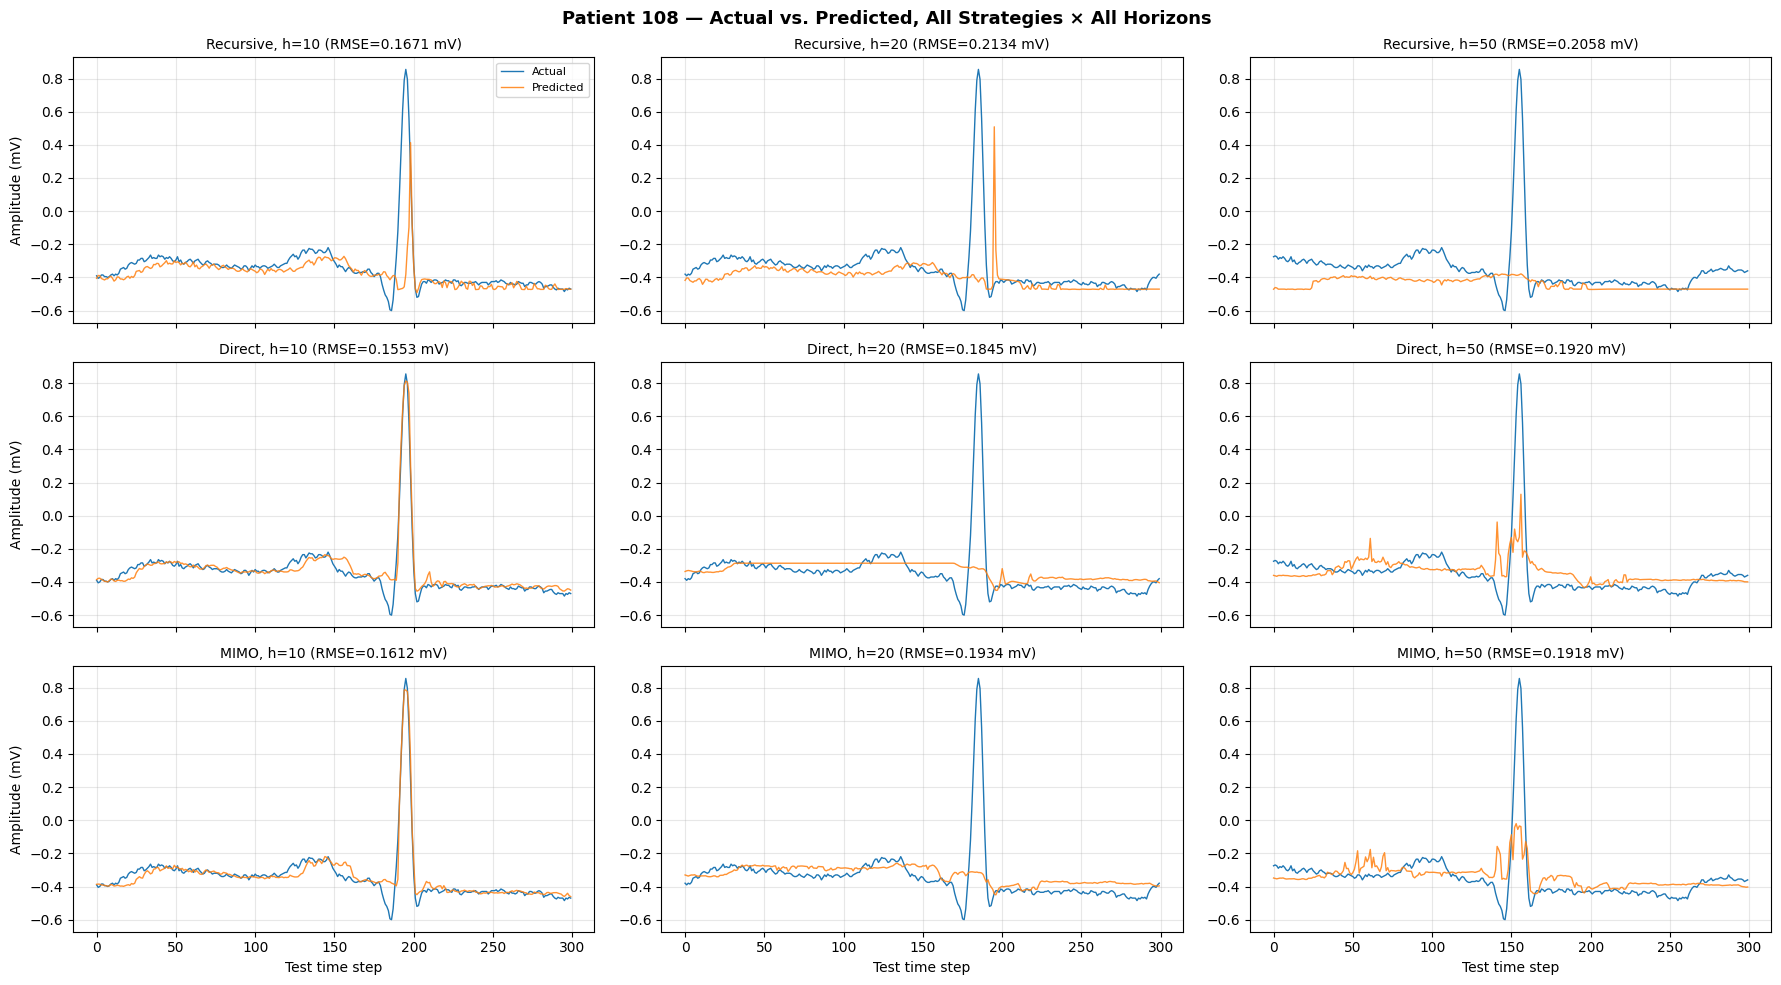

In [74]:
np.random.seed(42)

all_patients = sorted(df_strategy['Patient'].unique())

random_patients = np.random.choice(
    all_patients,
    size=5,
    replace=False
)

print("Selected random patients:")
for i, patient in enumerate(random_patients, 1):
    print(f"{i}. Patient {patient}")

n_show = 300
strategies = ['Recursive', 'Direct', 'MIMO']

for REP_PATIENT in random_patients:

    fig, axes = plt.subplots(
        3, 3,
        figsize=(18, 10),
        sharex=True
    )

    for row, strat in enumerate(strategies):

        for col, h in enumerate(FORECAST_HORIZONS):

            ax = axes[row, col]

            y_true_mv, y_pred_mv = demo_predictions[
                (strat, h)
            ]

            ax.plot(
                y_true_mv[:n_show],
                linewidth=1.0,
                label='Actual'
            )

            ax.plot(
                y_pred_mv[:n_show],
                linewidth=1.0,
                alpha=0.85,
                label='Predicted'
            )

            rmse_values = df_strategy[
                (df_strategy['Patient'] == REP_PATIENT) &
                (df_strategy['Strategy'] == strat) &
                (df_strategy['Horizon'] == h)
            ]['RMSE'].values

            if len(rmse_values) > 0:
                rmse_here = rmse_values[0]
            else:
                rmse_here = np.nan

            ax.set_title(
                f'{strat}, h={h} '
                f'(RMSE={rmse_here:.4f} mV)',
                fontsize=10
            )

            if row == 2:
                ax.set_xlabel('Test time step')

            if col == 0:
                ax.set_ylabel('Amplitude (mV)')

            if row == 0 and col == 0:
                ax.legend(fontsize=8)

            ax.grid(True, alpha=0.3)

    fig.suptitle(
        f'Patient {REP_PATIENT} — '
        f'Actual vs. Predicted, All Strategies × All Horizons',
        fontsize=13,
        fontweight='bold'
    )

    plt.tight_layout()

    plt.savefig(
        f'patient_{REP_PATIENT}_actual_vs_predicted_grid.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

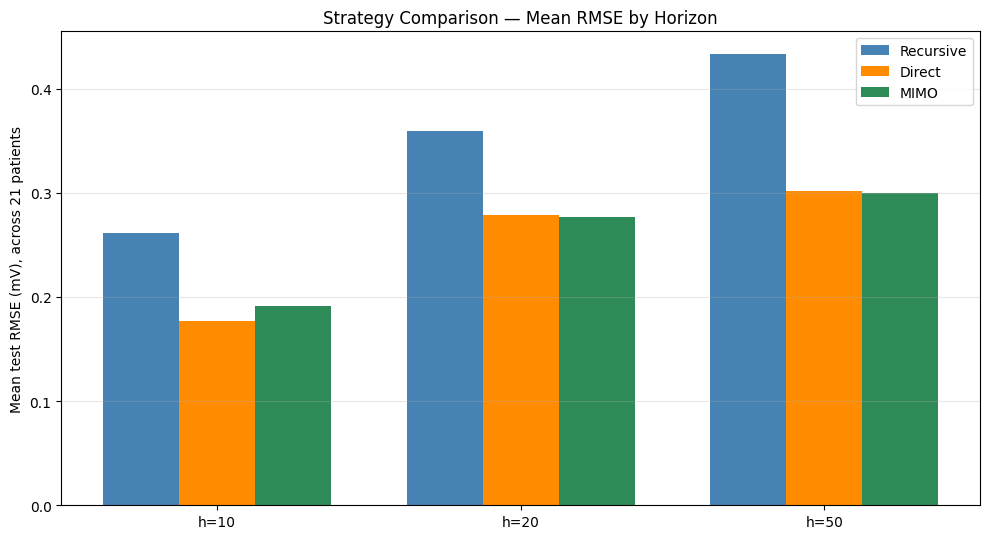

In [75]:
# 16b. Grouped bar chart: mean RMSE across all 21 patients, by strategy and horizon
fig, ax = plt.subplots(figsize=(10, 5.5))
width = 0.25
x = np.arange(len(FORECAST_HORIZONS))
colors = {'Recursive': 'steelblue', 'Direct': 'darkorange', 'MIMO': 'seagreen'}

for i, strat in enumerate(strategies):
    means = [df_strategy[(df_strategy['Strategy'] == strat) & (df_strategy['Horizon'] == h)]['RMSE'].mean()
             for h in FORECAST_HORIZONS]
    ax.bar(x + (i - 1) * width, means, width, label=strat, color=colors[strat])

ax.set_xticks(x)
ax.set_xticklabels([f'h={h}' for h in FORECAST_HORIZONS])
ax.set_ylabel('Mean test RMSE (mV), across 21 patients')
ax.set_title('Strategy Comparison — Mean RMSE by Horizon')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('strategy_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()
